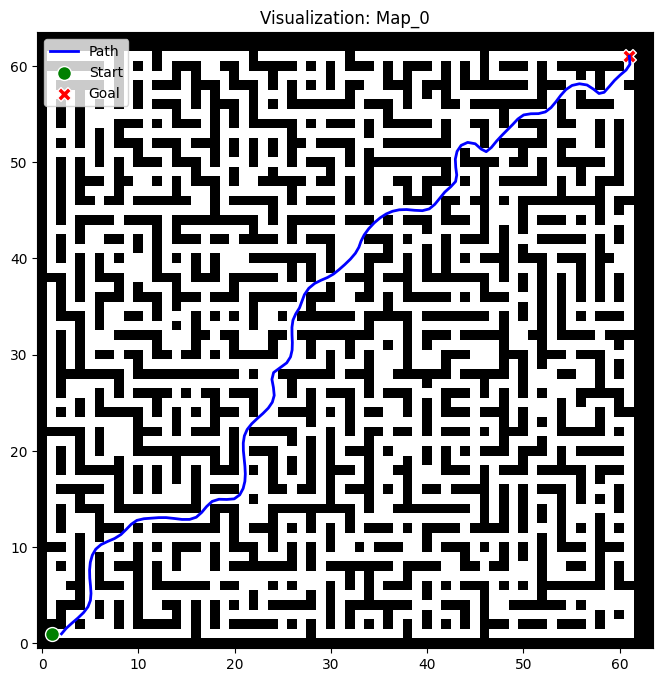

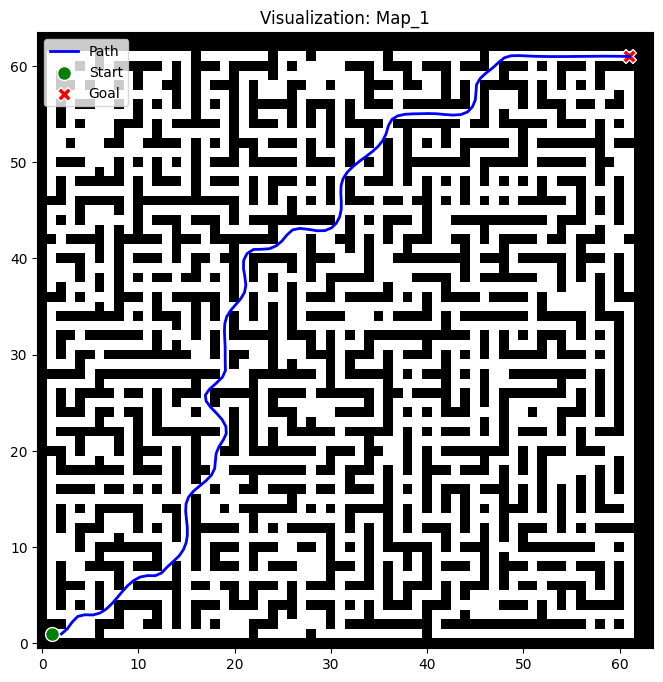

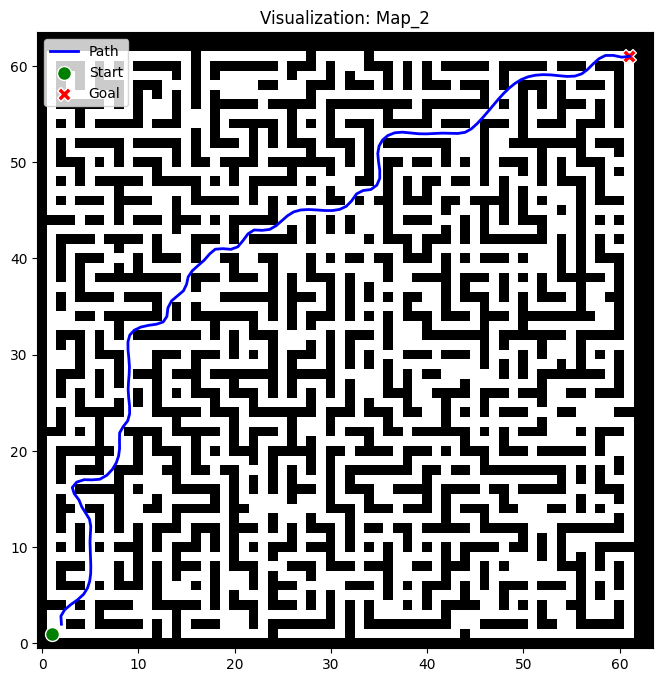

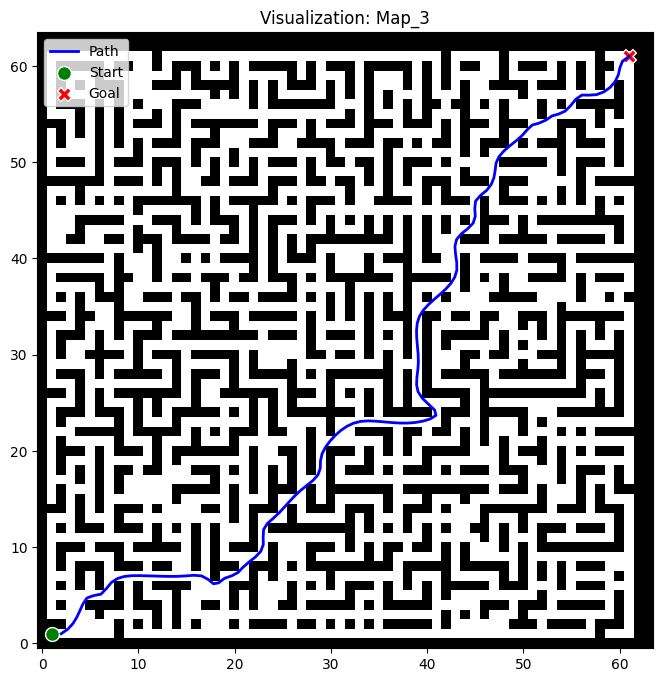

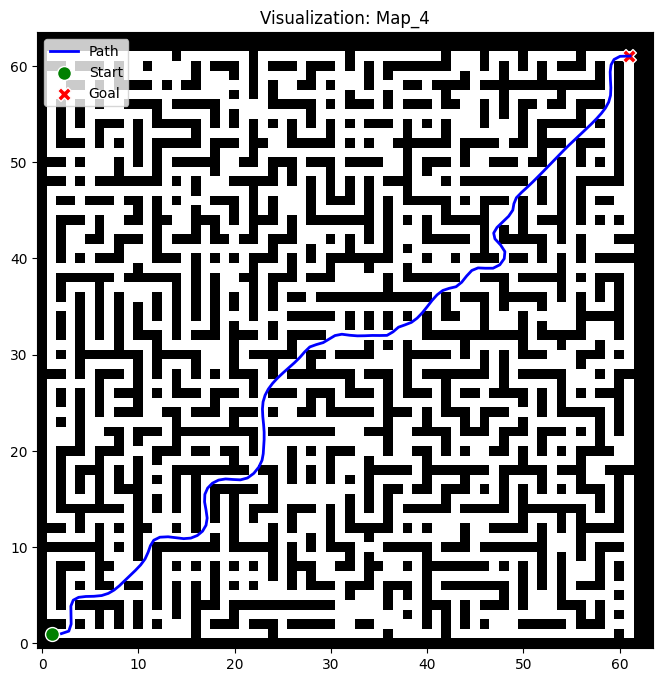

Done. Visualized first 5 maps and stored all 10 maps in map_dictionary.


In [50]:
import random
import heapq
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import splprep, splev

def B_spline(a_star_path, s=0.0, k=3, num_points=100):
    path = np.array(a_star_path)
    x = path[:, 0]
    y = path[:, 1]

    tck, _ = splprep([x, y], s=s, k=k)

    u_fine = np.linspace(0, 1, num_points)
    x_smooth, y_smooth = splev(u_fine, tck)

    return np.vstack((x_smooth, y_smooth)).T

# In Cell 1, replace the old generate_map with this:
def generate_map(size=64, multiplier=1, loop_prob=0.3):
    # For multiplier = 1, we generate a maze on the largest odd size
    # that fits (size - 1) to ensure the algorithm logic works.
    if multiplier == 1:
        effective_size = size - 1
    else:
        effective_size = size // multiplier
        if effective_size % 2 == 0: effective_size -= 1

    # 1. Generate the Skeleton on the effective_size
    skeleton = np.ones((effective_size, effective_size))
    stack = [(1, 1)]
    skeleton[1, 1] = 0
    visited = {(1, 1)}

    while stack:
        x, y = stack[-1]
        neighbors = []
        for dx, dy in [(0, -2), (0, 2), (-2, 0), (2, 0)]:
            nx, ny = x + dx, y + dy
            if 0 < nx < effective_size-1 and 0 < ny < effective_size-1 and (nx, ny) not in visited:
                neighbors.append((nx, ny, x + dx//2, y + dy//2))
        if neighbors:
            nx, ny, wx, wy = random.choice(neighbors)
            skeleton[ny, nx] = 0
            skeleton[wy, wx] = 0
            visited.add((nx, ny))
            stack.append((nx, ny))
        else:
            stack.pop()

    # 2. Add Loops (Braiding)
    for y in range(1, effective_size - 1):
        for x in range(1, effective_size - 1):
            if skeleton[y, x] == 1:
                if (skeleton[y, x-1] == 0 and skeleton[y, x+1] == 0) or \
                   (skeleton[y-1, x] == 0 and skeleton[y+1, x] == 0):
                    if random.random() < loop_prob:
                        skeleton[y, x] = 0

    # 3. Create the final grid of exactly 'size'
    final_grid = np.ones((size, size))

    # Upscale and place into the final grid
    for r in range(effective_size):
        for c in range(effective_size):
            if skeleton[r, c] == 0:
                # This places the upscaled skeleton into the top-left of the final_grid
                final_grid[r*multiplier : (r+1)*multiplier,
                           c*multiplier : (c+1)*multiplier] = 0

    # Set start and goal based on the generated skeleton area
    start = (multiplier, multiplier)
    goal = ((effective_size - 2) * multiplier, (effective_size - 2) * multiplier)

    return final_grid, start, goal

def a_star(grid, start, goal):
    size = grid.shape[0]
    neighbors = [
        (0, 1), (0, -1), (1, 0), (-1, 0),  
        (1, 1), (1, -1), (-1, 1), (-1, -1)   
    ]

    close_set = set()
    came_from = {}
    gscore = {start: 0}
    fscore = {start: np.linalg.norm(np.array(start) - np.array(goal))}
    oheap = []

    heapq.heappush(oheap, (fscore[start], start))

    while oheap:
        current = heapq.heappop(oheap)[1]

        if current == goal:
            data = []
            while current in came_from:
                data.append(current)
                current = came_from[current]
            return data[::-1]

        close_set.add(current)
        for i, j in neighbors:
            neighbor = current[0] + i, current[1] + j
            move_cost = np.sqrt(i**2 + j**2)
            tentative_g_score = gscore[current] + move_cost

            if 0 <= neighbor[0] < size and 0 <= neighbor[1] < size:
                if grid[neighbor[0], neighbor[1]] == 1:
                    continue
            else:
                continue

            if neighbor in close_set and tentative_g_score >= gscore.get(neighbor, 0):
                continue

            if tentative_g_score < gscore.get(neighbor, 0) or neighbor not in [n[1] for n in oheap]:
                came_from[neighbor] = current
                gscore[neighbor] = tentative_g_score
                fscore[neighbor] = tentative_g_score + np.linalg.norm(np.array(neighbor) - np.array(goal))
                heapq.heappush(oheap, (fscore[neighbor], neighbor))

    return None

def visualize_path(map_data, start, goal, path=None, map_id="Map"):
    plt.figure(figsize=(8, 8))
    plt.imshow(map_data, cmap='Greys', origin='lower')

    if path is not None and len(path) > 0:
        path_np = np.array(path)
        plt.plot(path_np[:, 1], path_np[:, 0], color='blue', linewidth=2, label='Path')

    plt.scatter(start[1], start[0], c='green', s=100, label='Start', marker='o', edgecolors='white')
    plt.scatter(goal[1], goal[0], c='red', s=100, label='Goal', marker='X', edgecolors='white')

    plt.title(f"Visualization: {map_id}")
    plt.legend()
    plt.grid(False)
    plt.show()

MAP_SIZE = 64
MAP_NUM = 10
PLOT_FIRST_N = 5

map_dictionary = {}

# Generate maps
for i in range(MAP_NUM):
    grid_map, start, goal = generate_map(size=MAP_SIZE, loop_prob=0.2)
    map_dictionary[f"Map_{i}"] = {
        "map": grid_map,
        "start": start,
        "goal": goal,
        "path": None,
        "smooth_path": None,
    }

# Run A* and B-spline smoothing; only visualize first 5 maps
for idx, (map_id, data) in enumerate(map_dictionary.items()):
    path = a_star(data['map'], data['start'], data['goal'])
    map_dictionary[map_id]['path'] = path

    if path is not None and len(path) >= 4:
        smooth_path = B_spline(path, s=1, k=3, num_points=128)
        map_dictionary[map_id]['smooth_path'] = smooth_path
    else:
        map_dictionary[map_id]['smooth_path'] = None

    if idx < PLOT_FIRST_N:
        path_to_show = map_dictionary[map_id]['smooth_path']
        if path_to_show is None:
            path_to_show = map_dictionary[map_id]['path']
        visualize_path(
            map_dictionary[map_id]['map'],
            map_dictionary[map_id]['start'],
            map_dictionary[map_id]['goal'],
            path_to_show,
            map_id,
        )

print(f"Done. Visualized first {PLOT_FIRST_N} maps and stored all {MAP_NUM} maps in map_dictionary.")

正在渲染動畫 (128 幀)...
✅ 動畫已儲存至: a_str_demo.gif


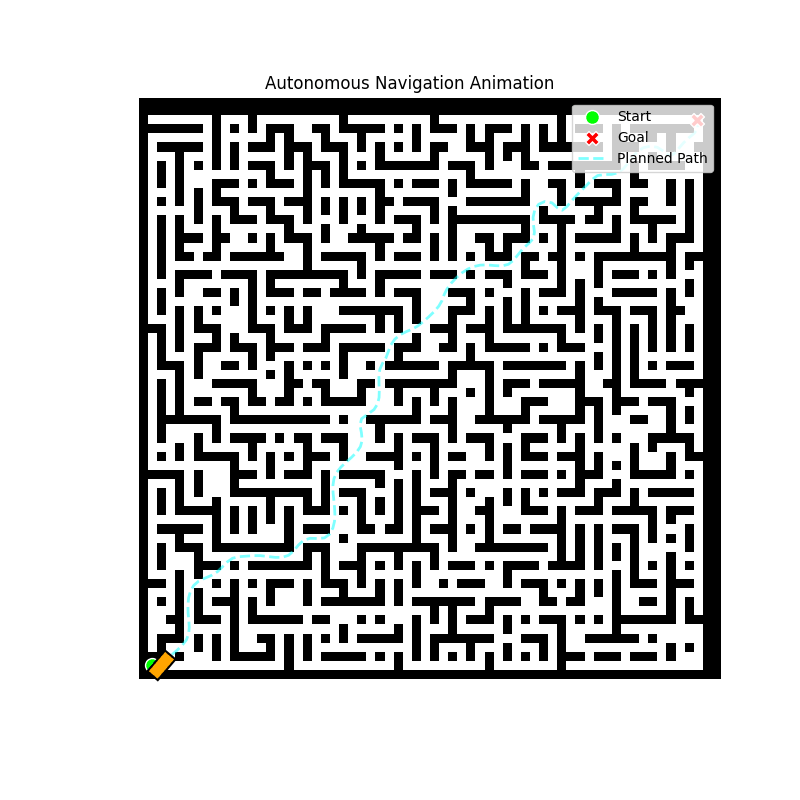

In [60]:
import matplotlib.animation as animation
import matplotlib.patches as patches
import matplotlib.transforms as transforms
from IPython.display import Image # 用於在 Jupyter 中直接顯示 GIF

# ==========================================
# 1. 定義動畫生成函數
# ==========================================
def create_car_animation(map_data, start, goal, path, filename="car_navigation.gif"):
    if path is None or len(path) < 2:
        print("路徑無效，無法生成動畫！")
        return

    # 準備畫布
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(map_data, cmap='Greys', origin='lower')
    
    # 畫出起點與終點
    ax.scatter(start[1], start[0], c='lime', s=100, marker='o', edgecolors='white', zorder=3, label='Start')
    ax.scatter(goal[1], goal[0], c='red', s=100, marker='X', edgecolors='white', zorder=3, label='Goal')
    
    # 準備路徑座標 (注意：你的 path 是 [row, col])
    path_np = np.array(path)
    path_y = path_np[:, 0]
    path_x = path_np[:, 1]
    
    # 畫出淡淡的預定軌跡
    ax.plot(path_x, path_y, color='cyan', linewidth=2, linestyle='--', alpha=0.5, label='Planned Path')

    # 2. 建立車子物件 (長方形)
    car_length = 3.0
    car_width = 1.5
    # 將中心設在 (0,0) 方便旋轉
    car = patches.Rectangle(
        (-car_length/2, -car_width/2), car_length, car_width, 
        linewidth=1.5, edgecolor='black', facecolor='orange', zorder=4
    )
    ax.add_patch(car)

    ax.set_title("Autonomous Navigation Animation")
    ax.legend(loc="upper right")
    ax.axis('off')

    # 3. 更新每一幀的函式
    def update(frame):
        cx, cy = path_x[frame], path_y[frame]
        
        # 計算車頭朝向 (θ = arctan2(Δy, Δx))
        if frame < len(path_x) - 1:
            nx, ny = path_x[frame+1], path_y[frame+1]
        else:
            # 最後一幀維持前一幀的朝向
            nx, ny = cx + (cx - path_x[frame-1]), cy + (cy - path_y[frame-1])
            
        angle_rad = np.arctan2(ny - cy, nx - cx)
        angle_deg = np.degrees(angle_rad)
        
        # 套用旋轉與平移變換
        t = transforms.Affine2D().rotate_deg(angle_deg).translate(cx, cy) + ax.transData
        car.set_transform(t)
        
        return car,

    # 4. 開始渲染並儲存
    print(f"正在渲染動畫 ({len(path_x)} 幀)...")
    ani = animation.FuncAnimation(fig, update, frames=len(path_x), interval=50, blit=True)
    
    # 儲存為 GIF
    ani.save(filename, writer='pillow', fps=20)
    plt.close()
    print(f"✅ 動畫已儲存至: {filename}")

# ==========================================
# 2. 執行並顯示結果
# ==========================================
# 確保 map_dictionary 已經存在且有資料
target_id = "Map_0"
if target_id in map_dictionary:
    data = map_dictionary[target_id]
    create_car_animation(
        map_data=data['map'],
        start=data['start'],
        goal=data['goal'],
        path=data['smooth_path'], # 使用 B-spline 產生的 128 個點
        filename="a_str_demo.gif"
    )
    
    # 在 Jupyter Notebook 中直接顯示出來
    display(Image(filename="a_str_demo.gif"))
else:
    print(f"找不到 {target_id}，請先執行地圖生成的單元格。")


In [53]:
import torch
from torch.utils.data import Dataset, DataLoader
from scipy.ndimage import distance_transform_edt
import numpy as np

def gaussian_heatmap(map_size, center, sigma=1.5):
    h, w = map_size
    cy, cx = float(center[0]), float(center[1])
    y = np.arange(h, dtype=np.float32)
    x = np.arange(w, dtype=np.float32)
    yy, xx = np.meshgrid(y, x, indexing='ij')
    heatmap = np.exp(-((yy - cy) ** 2 + (xx - cx) ** 2) / (2.0 * sigma * sigma))
    return heatmap.astype(np.float32)


def add_gaussian_brush(mask, r, c, sigma=1.2):
    h, w = mask.shape
    radius = int(np.ceil(3.0 * sigma))

    r0 = max(0, int(np.floor(r)) - radius)
    r1 = min(h - 1, int(np.floor(r)) + radius)
    c0 = max(0, int(np.floor(c)) - radius)
    c1 = min(w - 1, int(np.floor(c)) + radius)

    ys = np.arange(r0, r1 + 1, dtype=np.float32)
    xs = np.arange(c0, c1 + 1, dtype=np.float32)
    yy, xx = np.meshgrid(ys, xs, indexing='ij')

    patch = np.exp(-((yy - r) ** 2 + (xx - c) ** 2) / (2.0 * sigma * sigma)).astype(np.float32)
    mask[r0:r1 + 1, c0:c1 + 1] = np.maximum(mask[r0:r1 + 1, c0:c1 + 1], patch)


class PathPlanningDataset(Dataset):
    def __init__(
        self,
        map_dict,
        map_size=64,
        start_goal_sigma=1.5,
        path_sigma=1.2,
        endpoint_tube_gain=1.2,
        endpoint_tube_sigma_scale=1.6,
        output_mode='trajectory',  # 'trajectory' (legacy) or 'mask' (Step 0~2)
    ):
        self.map_size = map_size
        self.coord_scale = float(map_size - 1)
        self.start_goal_sigma = start_goal_sigma
        self.path_sigma = path_sigma
        self.endpoint_tube_gain = endpoint_tube_gain
        self.endpoint_tube_sigma_scale = endpoint_tube_sigma_scale
        self.output_mode = output_mode
        self.data_list = [v for _, v in map_dict.items() if v.get('smooth_path') is not None]

        # 預先計算每張地圖到最近障礙物的距離 (給 legacy trajectory pipeline 用)
        self.dist_maps = []
        for item in self.data_list:
            occ = item['map'].astype(np.float32)          # 0: free, 1: obstacle
            free_mask = (occ < 0.5).astype(np.uint8)      # free=1, obstacle=0
            dist_map = distance_transform_edt(free_mask).astype(np.float32)
            self.dist_maps.append(dist_map)

    def __len__(self):
        return len(self.data_list)

    def _build_cond(self, item):
        occ = item['map'].astype(np.float32)  # 0/1, shape [64,64]
        start_hm = gaussian_heatmap((self.map_size, self.map_size), item['start'], sigma=self.start_goal_sigma)
        goal_hm = gaussian_heatmap((self.map_size, self.map_size), item['goal'], sigma=self.start_goal_sigma)
        cond = np.stack([occ, start_hm, goal_hm], axis=0).astype(np.float32)  # [3,64,64]
        return cond

    def _build_soft_path_mask(self, item):
        # Step 0 + Step 2: soft mask + smooth_path continuous coordinates
        occ = item['map'].astype(np.float32)
        smooth_path = np.asarray(item['smooth_path'], dtype=np.float32)  # [N,2] as (row,col)
        smooth_path = np.clip(smooth_path, 0.0, self.coord_scale)

        mask = np.zeros((self.map_size, self.map_size), dtype=np.float32)
        for r, c in smooth_path:
            add_gaussian_brush(mask, float(r), float(c), sigma=self.path_sigma)

        # Slightly thicken near endpoints to emphasize connectivity anchors
        endpoint_sigma = self.path_sigma * self.endpoint_tube_sigma_scale
        s_r, s_c = item['start']
        g_r, g_c = item['goal']

        endpoint_boost = np.zeros_like(mask)
        add_gaussian_brush(endpoint_boost, float(s_r), float(s_c), sigma=endpoint_sigma)
        add_gaussian_brush(endpoint_boost, float(g_r), float(g_c), sigma=endpoint_sigma)
        mask = np.maximum(mask, np.clip(endpoint_boost * self.endpoint_tube_gain, 0.0, 1.0))

        # 保持值域 [0,1] 並避免畫到障礙物
        mask = np.clip(mask, 0.0, 1.0)
        mask = mask * (1.0 - occ)
        return mask.astype(np.float32)

    def __getitem__(self, idx):
        item = self.data_list[idx]

        # New mask pipeline (for image diffusion, Step 0~2)
        if self.output_mode == 'mask':
            cond = self._build_cond(item)                        # [3,64,64]
            path_mask = self._build_soft_path_mask(item)         # [64,64], soft in [0,1]
            cond_tensor = torch.from_numpy(cond)                 # [3,64,64]
            path_tensor = torch.from_numpy(path_mask).unsqueeze(0)  # [1,64,64]
            return path_tensor, cond_tensor

        # Legacy trajectory pipeline (kept for compatibility with existing training code)
        traj = item['smooth_path'].copy()  # [128, 2], (row, col)
        traj = np.clip(traj, 0.0, self.coord_scale)
        traj = (traj / self.coord_scale) * 2.0 - 1.0
        traj_tensor = torch.from_numpy(traj).float().permute(1, 0)  # [2, 128]

        map_arr = item['map'].astype(np.float32)
        map_arr = map_arr * 2.0 - 1.0
        map_tensor = torch.from_numpy(map_arr).unsqueeze(0)  # [1, 64, 64]

        start = item['start']
        goal = item['goal']
        goal_vals = torch.tensor([
            start[0] / self.coord_scale, start[1] / self.coord_scale,
            goal[0] / self.coord_scale, goal[1] / self.coord_scale,
        ]).float()
        goal_tensor = goal_vals * 2.0 - 1.0

        dist_tensor = torch.from_numpy(self.dist_maps[idx]).unsqueeze(0)  # [1, 64, 64]

        return traj_tensor, map_tensor, goal_tensor, dist_tensor


# 保留原本訓練流程用的 Dataset / DataLoader
legacy_dataset = PathPlanningDataset(map_dictionary, map_size=64, output_mode='trajectory')
train_loader = DataLoader(legacy_dataset, batch_size=256, shuffle=True)
print(f"Legacy trajectory dataset size: {len(legacy_dataset)}")

# 新增 Step 0~2 的影像 diffusion 訓練資料
mask_dataset = PathPlanningDataset(
    map_dictionary,
    map_size=64,
    start_goal_sigma=1.5,
    path_sigma=1.2,
    endpoint_tube_gain=1.2,
    endpoint_tube_sigma_scale=1.6,
    output_mode='mask',
)
mask_loader = DataLoader(mask_dataset, batch_size=256, shuffle=True)

sample_x0, sample_cond = mask_dataset[0]
print(f"Mask dataset size: {len(mask_dataset)}")
print(f"x0 (path mask) shape: {sample_x0.shape}, range=({sample_x0.min().item():.3f}, {sample_x0.max().item():.3f})")
print(f"cond shape: {sample_cond.shape}, occ range=({sample_cond[0].min().item():.1f}, {sample_cond[0].max().item():.1f})")

Legacy trajectory dataset size: 10
Mask dataset size: 10
x0 (path mask) shape: torch.Size([1, 64, 64]), range=(0.000, 1.000)
cond shape: torch.Size([3, 64, 64]), occ range=(0.0, 1.0)


In [54]:
!nvidia-smi

Sun Mar  8 21:23:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 576.76                 Driver Version: 576.76         CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5060 ...  WDDM  |   00000000:64:00.0 Off |                  N/A |
| N/A   41C    P8              3W /   72W |     178MiB /   8151MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Loaded pretrained checkpoint for inference: c:\Users\Juang\OneDrive\Desktop\WIN26\ECE285\Project\Conditional-Diffusion-Models-for-Robot-Path-Generation-separate-map\model\ddpm_path_model_20260305-035914.pt
Step 4 selected threshold (connectivity-first): 0.60, use_lcc=False
Step 6 path found: True
Raw path points: 79 | Resampled path points: 256


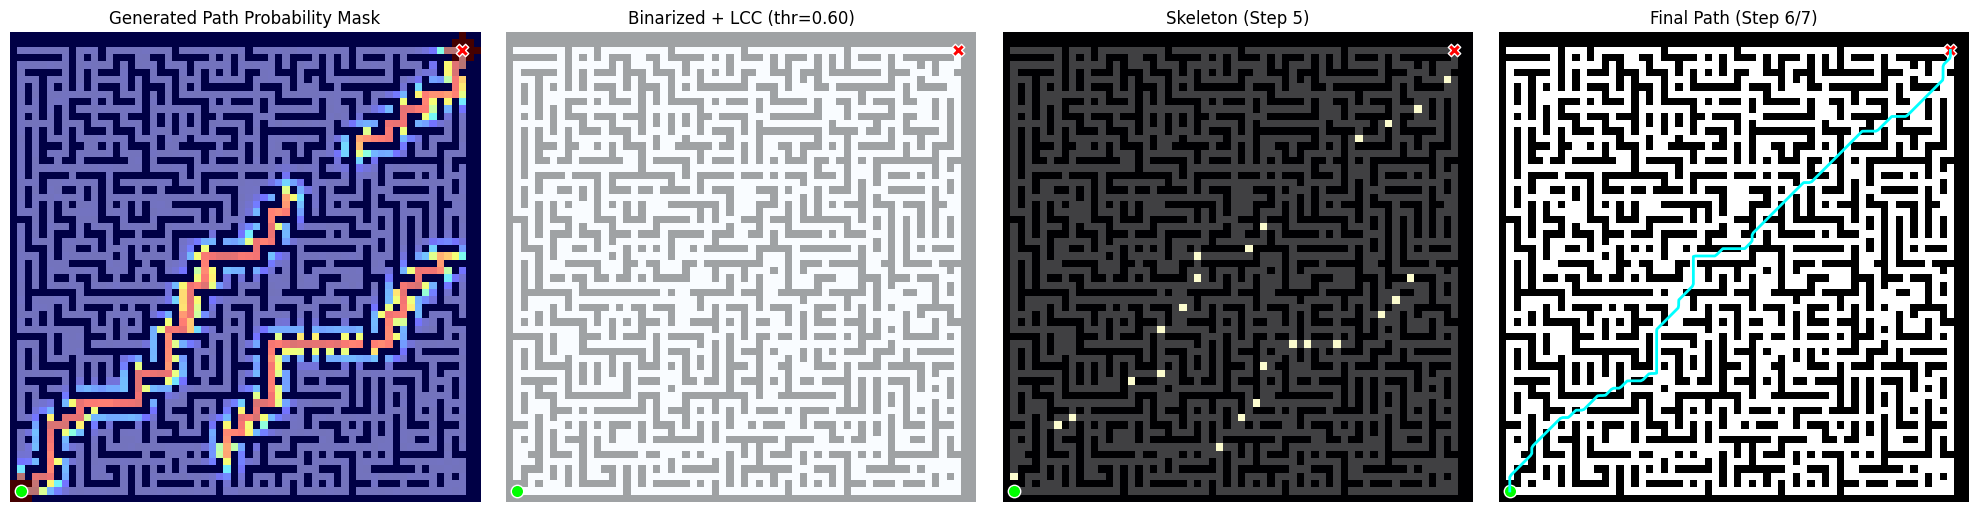

In [55]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from scipy.ndimage import label, binary_closing, binary_dilation, gaussian_filter, maximum_filter
from scipy.sparse.csgraph import minimum_spanning_tree
from skimage.morphology import skeletonize
from collections import deque
import heapq

# --- 1. 超參數設定 (Image DDPM + Step 4~7) ---
IMG_SIZE = 64
N_STEPS = 100
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TIME_EMBED_DIM = 128
START_GOAL_SIGMA = 1.5
PATH_BRUSH_SIGMA = 1.2
THRESHOLD = 0.45
THR_CANDIDATES = np.arange(0.15, 0.61, 0.05)
USE_LARGEST_CC = False
SKELETON_PRE_CLOSING = 1
SKELETON_PRE_DILATION = 0
PATH_LENGTH = 256
SKELETON_SNAP_MAX = 5.0
POSTPROC_ENDPOINT_SEED_RADIUS = 2
ENDPOINT_SEED_RADIUS = 2
ENDPOINT_SEED_VALUE = 1.0
ENDPOINT_WEIGHT_K = 4.0
ENDPOINT_SOFT_GAIN = 0.35
LAMBDA_PATH = 1.0
LAMBDA_CONNECT = 0.5
CONNECTIVITY_STEPS = 24
ENDPOINT_DISK_RADIUS = 2
CONNECT_GUIDE_SCALE = 0.08
CONNECT_GUIDE_STEPS = 16
CONNECT_GUIDE_TEMP = 0.35
SOFT_CLOSE_SIGMA = 1.0
SOFT_CLOSE_WEIGHT = 0.55
DISTFIELD_BASE_THR = 0.20
DISTFIELD_RIDGE_MIN = 0.45
MST_BRIDGE_RADIUS = 10.0
BRIDGE_OBSTACLE_PENALTY = 100.0
BRIDGE_PROB_PENALTY = 2.5
BRIDGE_LENGTH_PENALTY = 0.35
SNAKE_REFINE_STEPS = 20
SNAKE_ALPHA = 0.18
SNAKE_BETA = 0.10
USE_PRETRAINED_FOR_INFERENCE = True
PRETRAINED_MODEL_DIR = "model"


# --- 2. 擴散排程 (DDPM, epsilon parameterization) ---
betas = torch.linspace(1e-4, 2e-2, N_STEPS, dtype=torch.float32, device=DEVICE)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)


def extract(a, t, x_shape):
    out = a.gather(0, t)
    return out.view(-1, *([1] * (len(x_shape) - 1)))


def q_sample(x0, t, noise):
    sqrt_alpha_bar_t = extract(sqrt_alphas_cumprod, t, x0.shape)
    sqrt_one_minus_alpha_bar_t = extract(sqrt_one_minus_alphas_cumprod, t, x0.shape)
    return sqrt_alpha_bar_t * x0 + sqrt_one_minus_alpha_bar_t * noise


def sinusoidal_time_embedding(t, dim):
    half_dim = dim // 2
    exponent = -np.log(10000.0) / max(half_dim - 1, 1)
    frequencies = torch.exp(torch.arange(half_dim, device=t.device, dtype=torch.float32) * exponent)
    args = t.float().unsqueeze(1) * frequencies.unsqueeze(0)
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)
    if dim % 2 == 1:
        emb = F.pad(emb, (0, 1))
    return emb


def _pick_gn_groups(num_channels, max_groups=8):
    for g in range(max_groups, 0, -1):
        if num_channels % g == 0:
            return g
    return 1


class ResBlock2D(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        g1 = _pick_gn_groups(out_ch)
        g2 = _pick_gn_groups(out_ch)

        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(g1, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(g2, out_ch)
        self.act = nn.Mish()

        self.time_proj = nn.Linear(time_dim, out_ch)
        self.res_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(x)
        h = self.norm1(h)

        time_bias = self.time_proj(t_emb).unsqueeze(-1).unsqueeze(-1)
        h = h + time_bias
        h = self.act(h)

        h = self.conv2(h)
        h = self.norm2(h)
        h = self.act(h)

        return h + self.res_conv(x)


class PathUNet2D(nn.Module):
    # input = concat(x_t[1ch], cond[3ch]) => 4ch
    # output = eps_pred[1ch]
    def __init__(self, time_embed_dim=TIME_EMBED_DIM):
        super().__init__()

        self.time_embed_dim = time_embed_dim
        self.time_mlp = nn.Sequential(
            nn.Linear(time_embed_dim, 128),
            nn.Mish(),
            nn.Linear(128, 128),
        )

        self.in_block = ResBlock2D(4, 64, 128)
        self.down1 = nn.Conv2d(64, 64, 4, stride=2, padding=1)   # 64->32

        self.down_block = ResBlock2D(64, 128, 128)
        self.down2 = nn.Conv2d(128, 128, 4, stride=2, padding=1) # 32->16

        self.mid_block = ResBlock2D(128, 128, 128)

        self.up2 = nn.ConvTranspose2d(128, 128, 4, stride=2, padding=1)   # 16->32
        self.up_block2 = ResBlock2D(128 + 128, 64, 128)

        self.up1 = nn.ConvTranspose2d(64, 64, 4, stride=2, padding=1)     # 32->64
        self.up_block1 = ResBlock2D(64 + 64, 64, 128)

        self.out_conv = nn.Conv2d(64, 1, 1)

    def forward(self, x_t, t, cond):
        model_input = torch.cat([x_t, cond], dim=1)  # [B,4,64,64]
        t_emb = sinusoidal_time_embedding(t, self.time_embed_dim)
        t_emb = self.time_mlp(t_emb)

        h1 = self.in_block(model_input, t_emb)
        d1 = self.down1(h1)

        h2 = self.down_block(d1, t_emb)
        d2 = self.down2(h2)

        mid = self.mid_block(d2, t_emb)

        u2 = self.up2(mid)
        u2 = self.up_block2(torch.cat([u2, h2], dim=1), t_emb)

        u1 = self.up1(u2)
        u1 = self.up_block1(torch.cat([u1, h1], dim=1), t_emb)

        return self.out_conv(u1)


# --- 3. 訓練設定 (predict epsilon) ---
denoise_model = PathUNet2D().to(DEVICE)
optimizer = torch.optim.Adam(denoise_model.parameters(), lr=1e-4)
LAMBDA_WALL = 2.0
LAMBDA_NEARWALL = 1.0
NEARWALL_EPS = 1e-3
n_epochs = 70


def load_latest_pretrained_model(model, optimizer=None, model_dir=PRETRAINED_MODEL_DIR, map_location=DEVICE):
    model_dir = str(model_dir)

    # In notebooks, cwd may not be the repo root. Search a few likely roots.
    candidate_dirs = []
    cwd = os.getcwd()
    candidate_dirs.append(model_dir)
    candidate_dirs.append(os.path.join(cwd, model_dir))

    p = os.path.abspath(cwd)
    for _ in range(4):
        candidate_dirs.append(os.path.join(p, model_dir))
        parent = os.path.dirname(p)
        if parent == p:
            break
        p = parent

    # de-duplicate while preserving order
    seen = set()
    uniq_dirs = []
    for d in candidate_dirs:
        d_abs = os.path.abspath(d)
        if d_abs in seen:
            continue
        seen.add(d_abs)
        uniq_dirs.append(d_abs)

    ckpt_files = []
    for d in uniq_dirs:
        ckpt_files.extend(glob.glob(os.path.join(d, '*.pt')))

    ckpt_files = sorted(ckpt_files)
    if len(ckpt_files) == 0:
        print(f"[load_latest_pretrained_model] cwd={cwd}")
        print(f"[load_latest_pretrained_model] searched={uniq_dirs}")
        return False, None

    ckpt_path = ckpt_files[-1]
    ckpt = torch.load(ckpt_path, map_location=map_location)

    if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
        state_dict = ckpt['model_state_dict']
    else:
        state_dict = ckpt

    model.load_state_dict(state_dict, strict=True)

    if optimizer is not None and isinstance(ckpt, dict) and 'optimizer_state_dict' in ckpt:
        try:
            optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        except Exception:
            pass

    model.eval()
    return True, ckpt_path


def _torch_disk_mask(h, w, center_rc, radius, device):
    rr = torch.arange(h, device=device).view(h, 1)
    cc = torch.arange(w, device=device).view(1, w)
    cr, cc0 = int(center_rc[0]), int(center_rc[1])
    disk = ((rr - cr) ** 2 + (cc - cc0) ** 2) <= (radius ** 2)
    return disk.float()


def endpoint_points_from_cond(cond_tensor):
    # cond_tensor: [B,3,H,W], channel1=start_hm, channel2=goal_hm
    b, _, h, w = cond_tensor.shape
    start_hm = cond_tensor[:, 1, :, :]
    goal_hm = cond_tensor[:, 2, :, :]

    s_idx = torch.argmax(start_hm.view(b, -1), dim=1)
    g_idx = torch.argmax(goal_hm.view(b, -1), dim=1)

    s_r = (s_idx // w).long()
    s_c = (s_idx % w).long()
    g_r = (g_idx // w).long()
    g_c = (g_idx % w).long()

    return s_r, s_c, g_r, g_c


def endpoint_seed_mask_from_cond(cond_tensor, radius=2):
    b, _, h, w = cond_tensor.shape
    s_r, s_c, g_r, g_c = endpoint_points_from_cond(cond_tensor)
    seed_mask = torch.zeros((b, 1, h, w), dtype=torch.float32, device=cond_tensor.device)

    for i in range(b):
        s_disk = _torch_disk_mask(h, w, (int(s_r[i].item()), int(s_c[i].item())), radius, cond_tensor.device)
        g_disk = _torch_disk_mask(h, w, (int(g_r[i].item()), int(g_c[i].item())), radius, cond_tensor.device)
        seed_mask[i, 0] = torch.maximum(s_disk, g_disk)

    return seed_mask


def _disk_mask_numpy(shape, center_rc, radius):
    h, w = shape
    rr, cc = np.ogrid[:h, :w]
    cr, cc0 = int(center_rc[0]), int(center_rc[1])
    return ((rr - cr) ** 2 + (cc - cc0) ** 2) <= (radius ** 2)


def build_nearwall_weight_from_occ(occ):
    # occ: [B,1,H,W], 0=free, 1=obstacle
    free = (1.0 - occ).clamp(0.0, 1.0)
    free_np = free.detach().cpu().numpy()

    dist_list = []
    for i in range(free_np.shape[0]):
        dist = distance_transform_edt(free_np[i, 0] > 0.5).astype(np.float32)
        dist_list.append(dist)

    dist = torch.from_numpy(np.stack(dist_list, axis=0)).unsqueeze(1).to(occ.device)
    nearwall_weight = free / (dist + NEARWALL_EPS)
    return nearwall_weight


def soft_connectivity_loss(x0_hat_prob, occ, g_start, g_goal, n_steps=24):
    # Differentiable surrogate: propagate reachability through predicted free corridor
    # from start and goal, and require bidirectional overlap at opposite endpoint.
    passable = (x0_hat_prob * (1.0 - occ)).clamp(0.0, 1.0)

    start_seed = (g_start / (g_start.amax(dim=(2, 3), keepdim=True) + 1e-6)).clamp(0.0, 1.0)
    goal_seed = (g_goal / (g_goal.amax(dim=(2, 3), keepdim=True) + 1e-6)).clamp(0.0, 1.0)

    reach_from_start = start_seed
    reach_from_goal = goal_seed

    for _ in range(int(n_steps)):
        reach_from_start = F.max_pool2d(reach_from_start, kernel_size=3, stride=1, padding=1)
        reach_from_start = (reach_from_start * passable).clamp(0.0, 1.0)

        reach_from_goal = F.max_pool2d(reach_from_goal, kernel_size=3, stride=1, padding=1)
        reach_from_goal = (reach_from_goal * passable).clamp(0.0, 1.0)

    s_to_g = (reach_from_start * goal_seed).amax(dim=(1, 2, 3))
    g_to_s = (reach_from_goal * start_seed).amax(dim=(1, 2, 3))
    conn_score = 0.5 * (s_to_g + g_to_s)

    return (1.0 - conn_score).mean()


def p_loss(x0, cond):
    b = x0.shape[0]
    t = torch.randint(0, N_STEPS, (b,), device=DEVICE)
    noise = torch.randn_like(x0)

    x_t = q_sample(x0, t, noise)
    noise_pred = denoise_model(x_t, t, cond)

    sqrt_alpha_bar_t = extract(sqrt_alphas_cumprod, t, x_t.shape)
    sqrt_one_minus_alpha_bar_t = extract(sqrt_one_minus_alphas_cumprod, t, x_t.shape)
    x0_hat = (x_t - sqrt_one_minus_alpha_bar_t * noise_pred) / (sqrt_alpha_bar_t + 1e-8)

    occ = cond[:, 0:1, :, :].clamp(0.0, 1.0)
    g_start = cond[:, 1:2, :, :].clamp(0.0, 1.0)
    g_goal = cond[:, 2:3, :, :].clamp(0.0, 1.0)
    w_end = 1.0 + ENDPOINT_WEIGHT_K * (g_start + g_goal)
    nearwall_weight = build_nearwall_weight_from_occ(occ)

    l_eps = (((noise_pred - noise) ** 2) * w_end).mean()

    x0_hat_prob = x0_hat.clamp(0.0, 1.0)
    soft_gt = F.avg_pool2d(x0, kernel_size=5, stride=1, padding=2)
    soft_gt = torch.clamp(soft_gt + ENDPOINT_SOFT_GAIN * (g_start + g_goal), 0.0, 1.0)
    l_path = F.mse_loss(x0_hat_prob, soft_gt)

    l_wall = ((x0_hat ** 2) * occ).mean()
    l_nearwall = ((x0_hat ** 2) * nearwall_weight).mean()
    l_connect = soft_connectivity_loss(x0_hat_prob, occ, g_start, g_goal, n_steps=CONNECTIVITY_STEPS)

    return l_eps + LAMBDA_PATH * l_path + LAMBDA_WALL * l_wall + LAMBDA_NEARWALL * l_nearwall + LAMBDA_CONNECT * l_connect


def p_sample(x_t, t, cond):
    eps_theta = denoise_model(x_t, t, cond)

    beta_t = extract(betas, t, x_t.shape)
    sqrt_one_minus_alpha_bar_t = extract(sqrt_one_minus_alphas_cumprod, t, x_t.shape)
    sqrt_recip_alpha_t = extract(sqrt_recip_alphas, t, x_t.shape)

    model_mean = sqrt_recip_alpha_t * (x_t - (beta_t / sqrt_one_minus_alpha_bar_t) * eps_theta)

    if t[0].item() == 0:
        return model_mean

    posterior_var_t = extract(posterior_variance, t, x_t.shape)
    noise = torch.randn_like(x_t)
    return model_mean + torch.sqrt(posterior_var_t) * noise


def connectivity_guidance_step(x_t, t, cond, free_mask, endpoint_seed_mask):
    if CONNECT_GUIDE_SCALE <= 0.0:
        return x_t

    x_var = x_t.detach().requires_grad_(True)
    occ = cond[:, 0:1, :, :].clamp(0.0, 1.0)
    g_start = cond[:, 1:2, :, :].clamp(0.0, 1.0)
    g_goal = cond[:, 2:3, :, :].clamp(0.0, 1.0)

    x_prob = torch.sigmoid(x_var / max(CONNECT_GUIDE_TEMP, 1e-4))
    l_conn = soft_connectivity_loss(x_prob, occ, g_start, g_goal, n_steps=CONNECT_GUIDE_STEPS)
    grad = torch.autograd.grad(l_conn, x_var, only_inputs=True)[0]

    t_scale = ((t.float() + 1.0) / float(N_STEPS)).view(-1, 1, 1, 1)
    x_guided = (x_var - CONNECT_GUIDE_SCALE * t_scale * grad).detach()
    x_guided = x_guided * free_mask
    x_guided = torch.maximum(x_guided, endpoint_seed_mask * ENDPOINT_SEED_VALUE)
    return x_guided


def generate_path_mask(cond_tensor):
    # cond_tensor: [1,3,64,64]
    x_gen = torch.randn(1, 1, IMG_SIZE, IMG_SIZE, device=DEVICE)
    cond_tensor = cond_tensor.to(DEVICE)
    free_mask = (1.0 - cond_tensor[:, 0:1, :, :]).clamp(0.0, 1.0)
    endpoint_seed_mask = endpoint_seed_mask_from_cond(cond_tensor, radius=ENDPOINT_SEED_RADIUS)

    denoise_model.eval()
    for i in range(N_STEPS - 1, -1, -1):
        t = torch.full((1,), i, dtype=torch.long, device=DEVICE)
        with torch.no_grad():
            x_gen = p_sample(x_gen, t, cond_tensor)
            x_gen = x_gen * free_mask
            x_gen = torch.maximum(x_gen, endpoint_seed_mask * ENDPOINT_SEED_VALUE)

        if i > 0 and CONNECT_GUIDE_SCALE > 0.0:
            # Guidance needs gradients even if caller wrapped inference in no_grad.
            with torch.enable_grad():
                x_gen = connectivity_guidance_step(x_gen, t, cond_tensor, free_mask, endpoint_seed_mask)

    x0_gen = x_gen.squeeze(0).squeeze(0)  # [64,64]
    x0_gen = x0_gen.clamp(0.0, 1.0)
    return x0_gen


# --- 4. Step 4 Postprocess: threshold + largest CC ---
def keep_largest_connected_component(mask_bin):
    mask_bool = mask_bin.astype(bool)
    labeled, num = label(mask_bool)
    if num == 0:
        return mask_bin.astype(np.float32)

    sizes = np.bincount(labeled.ravel())
    sizes[0] = 0
    largest_label = sizes.argmax()
    return (labeled == largest_label).astype(np.float32)


def keep_endpoint_connected_component(mask_bin, start_rc, goal_rc, endpoint_radius=2):
    mask_bool = mask_bin.astype(bool)
    labeled, num = label(mask_bool)
    if num == 0:
        return np.zeros_like(mask_bin, dtype=np.float32), False

    start_disk = _disk_mask_numpy(mask_bin.shape, start_rc, endpoint_radius)
    goal_disk = _disk_mask_numpy(mask_bin.shape, goal_rc, endpoint_radius)

    best_comp = None
    best_size = -1
    for comp_id in range(1, num + 1):
        comp = (labeled == comp_id)
        hit_start = np.logical_and(comp, start_disk).any()
        hit_goal = np.logical_and(comp, goal_disk).any()
        if hit_start and hit_goal:
            comp_size = int(comp.sum())
            if comp_size > best_size:
                best_size = comp_size
                best_comp = comp

    if best_comp is not None:
        return best_comp.astype(np.float32), True

    return np.zeros_like(mask_bin, dtype=np.float32), False

def soft_close_probability_mask(prob_mask, free_mask=None, sigma=1.0, blend=0.35):
    p = np.clip(prob_mask.astype(np.float32), 0.0, 1.0)
    p_smooth = gaussian_filter(p, sigma=float(sigma))
    p_out = np.clip((1.0 - float(blend)) * p + float(blend) * p_smooth, 0.0, 1.0)
    if free_mask is not None:
        p_out = p_out * free_mask.astype(np.float32)
    return p_out


def postprocess_mask(prob_mask, free_mask=None, thr=0.45, use_lcc=True, start_rc=None, goal_rc=None, morph_schedule=None):
    prob_soft = soft_close_probability_mask(prob_mask, free_mask=free_mask, sigma=SOFT_CLOSE_SIGMA, blend=SOFT_CLOSE_WEIGHT)
    mask_bin = (prob_soft > float(thr)).astype(np.float32)
    if free_mask is not None:
        mask_bin = mask_bin * free_mask.astype(np.float32)

    if start_rc is not None and goal_rc is not None:
        endpoint_seed = np.logical_or(
            _disk_mask_numpy(mask_bin.shape, start_rc, POSTPROC_ENDPOINT_SEED_RADIUS),
            _disk_mask_numpy(mask_bin.shape, goal_rc, POSTPROC_ENDPOINT_SEED_RADIUS),
        ).astype(np.float32)
        if free_mask is not None:
            endpoint_seed = endpoint_seed * free_mask.astype(np.float32)
        mask_bin = np.maximum(mask_bin, endpoint_seed)

        if morph_schedule is None:
            morph_schedule = [(0, 0), (1, 0), (2, 0), (2, 1), (3, 1)]

        base_bool = mask_bin.astype(bool)
        for closing_iter, dilation_iter in morph_schedule:
            cand = base_bool.copy()
            for _ in range(closing_iter):
                cand = binary_closing(cand)
            for _ in range(dilation_iter):
                cand = binary_dilation(cand)

            cand = cand.astype(np.float32)
            if free_mask is not None:
                cand = cand * free_mask.astype(np.float32)
            cand = np.maximum(cand, endpoint_seed)

            picked, ok = keep_endpoint_connected_component(cand, start_rc, goal_rc, endpoint_radius=ENDPOINT_DISK_RADIUS)
            if ok:
                return picked

        return np.zeros_like(mask_bin, dtype=np.float32)

    if use_lcc:
        return keep_largest_connected_component(mask_bin)
    return mask_bin


def select_threshold_by_connectivity(prob_mask, free_mask, start_rc, goal_rc, thr_values=THR_CANDIDATES, use_lcc=True):
    thr_desc = sorted([float(t) for t in thr_values], reverse=True)

    # Phase 1: highest threshold that works with minimal morphology
    minimal_schedule = [(1, 0)]
    for thr in thr_desc:
        cand = postprocess_mask(
            prob_mask,
            free_mask=free_mask,
            thr=thr,
            use_lcc=False,
            start_rc=start_rc,
            goal_rc=goal_rc,
            morph_schedule=minimal_schedule,
        )
        _, ok = keep_endpoint_connected_component(cand, start_rc, goal_rc, endpoint_radius=ENDPOINT_DISK_RADIUS)
        if ok:
            return thr, cand

    # Phase 2: adaptive morphology only when needed
    adaptive_schedule = [(1, 0), (2, 0), (2, 1), (3, 1)]
    for thr in thr_desc:
        cand = postprocess_mask(
            prob_mask,
            free_mask=free_mask,
            thr=thr,
            use_lcc=False,
            start_rc=start_rc,
            goal_rc=goal_rc,
            morph_schedule=adaptive_schedule,
        )
        _, ok = keep_endpoint_connected_component(cand, start_rc, goal_rc, endpoint_radius=ENDPOINT_DISK_RADIUS)
        if ok:
            return thr, cand

    fallback_thr = float(thr_desc[0]) if len(thr_desc) > 0 else float(THRESHOLD)
    fallback_mask = postprocess_mask(
        prob_mask,
        free_mask=free_mask,
        thr=fallback_thr,
        use_lcc=False,
        start_rc=start_rc,
        goal_rc=goal_rc,
        morph_schedule=adaptive_schedule,
    )
    return fallback_thr, fallback_mask


def iou_score(mask_a, mask_b, eps=1e-6):
    a = mask_a.astype(bool)
    b = mask_b.astype(bool)
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return float(inter) / float(union + eps)


def build_soft_mask_from_item(item, map_size=64, path_sigma=1.2):
    occ = item['map'].astype(np.float32)
    smooth_path = np.asarray(item['smooth_path'], dtype=np.float32)
    smooth_path = np.clip(smooth_path, 0.0, float(map_size - 1))

    gt_mask = np.zeros((map_size, map_size), dtype=np.float32)
    for r, c in smooth_path:
        add_gaussian_brush(gt_mask, float(r), float(c), sigma=path_sigma)

    gt_mask = np.clip(gt_mask, 0.0, 1.0)
    gt_mask = gt_mask * (1.0 - occ)
    return gt_mask


def sweep_threshold(prob_mask, gt_mask, free_mask=None, start_rc=None, goal_rc=None, thr_values=THR_CANDIDATES, use_lcc=True):
    best_thr = thr_values[0]
    best_iou = -1.0
    records = []

    for thr in thr_values:
        pred_bin = postprocess_mask(prob_mask, free_mask=free_mask, thr=thr, use_lcc=use_lcc, start_rc=start_rc, goal_rc=goal_rc)
        score = iou_score(pred_bin, gt_mask > 0.5)
        records.append((float(thr), float(score)))
        if score > best_iou:
            best_iou = score
            best_thr = float(thr)

    return best_thr, best_iou, records


def build_cond_from_item(item, map_size=64, sigma=1.5):
    occ = item['map'].astype(np.float32)
    start_hm = gaussian_heatmap((map_size, map_size), item['start'], sigma=sigma)
    goal_hm = gaussian_heatmap((map_size, map_size), item['goal'], sigma=sigma)
    cond = np.stack([occ, start_hm, goal_hm], axis=0).astype(np.float32)
    return torch.from_numpy(cond).unsqueeze(0)  # [1,3,64,64]


# --- 5. Step 5/6/7: distance-field skeleton + MST-bridged routing + output format ---
def skeletonize_from_distance_field(prob_mask, free_mask=None, base_thr=DISTFIELD_BASE_THR, ridge_min=DISTFIELD_RIDGE_MIN):
    prob_soft = soft_close_probability_mask(prob_mask, free_mask=free_mask, sigma=SOFT_CLOSE_SIGMA, blend=SOFT_CLOSE_WEIGHT)
    support = prob_soft > float(base_thr)

    if free_mask is not None:
        support = support.astype(np.float32) * np.clip(free_mask.astype(np.float32), 0.0, 1.0)
        support = support > 0.5

    if support.sum() == 0:
        return np.zeros_like(prob_soft, dtype=bool)

    dist = distance_transform_edt(support).astype(np.float32)
    dist = dist * prob_soft
    local_max = dist >= maximum_filter(dist, size=3)
    ridge = np.logical_and(local_max, dist >= float(ridge_min))
    ridge = np.logical_and(ridge, support)

    if ridge.sum() == 0:
        ridge = support

    skel = skeletonize(ridge)
    return skel


def nearest_skeleton_pixel(skel, point_rc, snap_max=None):
    coords = np.argwhere(skel)
    if len(coords) == 0:
        return None

    p = np.array(point_rc, dtype=np.float32)
    d2 = ((coords.astype(np.float32) - p[None, :]) ** 2).sum(axis=1)
    idx = int(np.argmin(d2))
    min_dist = float(np.sqrt(d2[idx]))
    if snap_max is not None and min_dist > float(snap_max):
        return None
    return tuple(coords[idx].tolist())


def _rasterize_line_pixels(point_a, point_b):
    p0 = np.asarray(point_a, dtype=np.float32)
    p1 = np.asarray(point_b, dtype=np.float32)
    n_steps = int(np.ceil(np.max(np.abs(p1 - p0)))) + 1
    n_steps = max(n_steps, 2)

    rr = np.linspace(p0[0], p1[0], n_steps)
    cc = np.linspace(p0[1], p1[1], n_steps)
    line = np.stack([np.round(rr).astype(int), np.round(cc).astype(int)], axis=1)

    pixels = []
    last_key = None
    for r, c in line.tolist():
        key = (int(r), int(c))
        if key != last_key:
            pixels.append(key)
            last_key = key
    return pixels


def _bridge_path_cost(line_pixels, prob_mask=None, free_mask=None, bridge_radius=MST_BRIDGE_RADIUS):
    if len(line_pixels) == 0:
        return 0.0, 0.0

    p0 = np.asarray(line_pixels[0], dtype=np.float32)
    p1 = np.asarray(line_pixels[-1], dtype=np.float32)
    euclid = float(np.linalg.norm(p1 - p0))
    cost = max(euclid, 1e-6)

    line_arr = np.asarray(line_pixels, dtype=np.int32)
    rr = line_arr[:, 0]
    cc = line_arr[:, 1]

    if free_mask is not None:
        free_vals = np.clip(free_mask[rr, cc].astype(np.float32), 0.0, 1.0)
        obstacle_ratio = float(np.mean(free_vals <= 0.5))
        obstacle_strength = float(np.mean(1.0 - free_vals))
        cost *= 1.0 + BRIDGE_OBSTACLE_PENALTY * obstacle_ratio + 4.0 * obstacle_strength

    if prob_mask is not None:
        prob_vals = np.clip(prob_mask[rr, cc].astype(np.float32), 0.0, 1.0)
        cost *= 1.0 + BRIDGE_PROB_PENALTY * float(np.mean(1.0 - prob_vals))

    if bridge_radius is not None and float(bridge_radius) > 0.0:
        over = max(euclid - float(bridge_radius), 0.0)
        cost *= 1.0 + BRIDGE_LENGTH_PENALTY * (over / float(bridge_radius))

    return cost, euclid


def _add_graph_edge(graph, edge_paths, u, v, weight, path_uv):
    path_fwd = [tuple(p) for p in path_uv]
    path_rev = list(reversed(path_fwd))
    graph[u].append((v, float(weight)))
    graph[v].append((u, float(weight)))
    edge_paths[(u, v)] = path_fwd
    edge_paths[(v, u)] = path_rev


def _build_component_bridge_candidates(coords, skel, prob_mask=None, free_mask=None, bridge_radius=MST_BRIDGE_RADIUS):
    structure = np.ones((3, 3), dtype=np.uint8)
    labeled_skel, n_components = label(skel.astype(np.uint8), structure=structure)
    if n_components <= 1:
        return []

    component_coords = []
    for comp_id in range(1, n_components + 1):
        pts = np.argwhere(labeled_skel == comp_id)
        if len(pts) > 0:
            component_coords.append(pts.astype(np.int32))

    n_comp = len(component_coords)
    if n_comp <= 1:
        return []

    comp_cost = np.zeros((n_comp, n_comp), dtype=np.float32)
    bridge_info = {}

    for i in range(n_comp):
        pts_i = component_coords[i].astype(np.float32)
        for j in range(i + 1, n_comp):
            pts_j = component_coords[j].astype(np.float32)
            diff = pts_i[:, None, :] - pts_j[None, :, :]
            dist2 = np.sum(diff * diff, axis=2)
            flat_idx = int(np.argmin(dist2))
            ii, jj = np.unravel_index(flat_idx, dist2.shape)

            point_i = tuple(component_coords[i][ii].tolist())
            point_j = tuple(component_coords[j][jj].tolist())
            line_pixels = _rasterize_line_pixels(point_i, point_j)
            cost, euclid = _bridge_path_cost(
                line_pixels,
                prob_mask=prob_mask,
                free_mask=free_mask,
                bridge_radius=bridge_radius,
            )

            comp_cost[i, j] = cost
            comp_cost[j, i] = cost
            bridge_info[(i, j)] = (point_i, point_j, line_pixels, cost, euclid)

    mst = minimum_spanning_tree(comp_cost).toarray().astype(np.float32)
    rr, cc = np.nonzero(mst > 0.0)

    bridges = []
    for i, j in zip(rr.tolist(), cc.tolist()):
        point_i, point_j, line_pixels, cost, euclid = bridge_info[(int(i), int(j))]
        bridges.append((point_i, point_j, line_pixels, float(cost), float(euclid)))
    return bridges


def _build_skeleton_graph_with_mst(skel, prob_mask=None, free_mask=None, bridge_radius=MST_BRIDGE_RADIUS):
    coords = np.argwhere(skel)
    n = len(coords)
    if n == 0:
        return coords, {}, {}

    idx_map = {tuple(coords[i].tolist()): i for i in range(n)}
    graph = {i: [] for i in range(n)}
    edge_paths = {}

    # Base 8-neighbor edges preserve local skeleton geometry.
    neigh = [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]
    for i, (r, c) in enumerate(coords):
        for dr, dc in neigh:
            key = (int(r + dr), int(c + dc))
            j = idx_map.get(key, None)
            if j is None or j <= i:
                continue
            w = float(np.hypot(dr, dc))
            _add_graph_edge(graph, edge_paths, i, j, w, [tuple(coords[i].tolist()), tuple(coords[j].tolist())])

    # Bridge disconnected skeleton components using an MST over components,
    # with costs penalizing obstacle crossings, low-probability jumps, and long gaps.
    bridges = _build_component_bridge_candidates(
        coords,
        skel,
        prob_mask=prob_mask,
        free_mask=free_mask,
        bridge_radius=bridge_radius,
    )
    for point_i, point_j, line_pixels, cost, _ in bridges:
        u = idx_map.get(tuple(point_i), None)
        v = idx_map.get(tuple(point_j), None)
        if u is None or v is None:
            continue
        _add_graph_edge(graph, edge_paths, u, v, cost, line_pixels)

    return coords, graph, edge_paths


def shortest_path_on_skeleton(skel, start_rc, goal_rc, snap_max=SKELETON_SNAP_MAX, prob_mask=None, free_mask=None):
    start_node = nearest_skeleton_pixel(skel, start_rc, snap_max=snap_max)
    goal_node = nearest_skeleton_pixel(skel, goal_rc, snap_max=snap_max)

    if start_node is None or goal_node is None:
        return None

    if start_node == goal_node:
        return [start_node]

    coords, graph, edge_paths = _build_skeleton_graph_with_mst(
        skel,
        prob_mask=prob_mask,
        free_mask=free_mask,
    )
    if len(coords) == 0:
        return None

    idx_map = {tuple(coords[i].tolist()): i for i in range(len(coords))}
    s_idx = idx_map.get(tuple(start_node), None)
    g_idx = idx_map.get(tuple(goal_node), None)
    if s_idx is None or g_idx is None:
        return None

    inf = 1e12
    dist = [inf] * len(coords)
    prev = [-1] * len(coords)
    dist[s_idx] = 0.0
    heap = [(0.0, s_idx)]

    while heap:
        cur_d, u = heapq.heappop(heap)
        if cur_d > dist[u]:
            continue
        if u == g_idx:
            break
        for v, w in graph.get(u, []):
            nd = cur_d + float(w)
            if nd < dist[v]:
                dist[v] = nd
                prev[v] = u
                heapq.heappush(heap, (nd, v))

    if prev[g_idx] == -1 and s_idx != g_idx:
        return None

    idx_path = [g_idx]
    while idx_path[-1] != s_idx:
        idx_path.append(prev[idx_path[-1]])
    idx_path.reverse()

    path_pixels = [tuple(coords[idx_path[0]].tolist())]
    for u, v in zip(idx_path[:-1], idx_path[1:]):
        edge_pixels = edge_paths.get((u, v), [tuple(coords[u].tolist()), tuple(coords[v].tolist())])
        path_pixels.extend(edge_pixels[1:])
    return path_pixels


def resample_path(path_rc, n_points=128):
    path = np.asarray(path_rc, dtype=np.float32)
    if len(path) == 0:
        return path
    if len(path) == 1:
        return np.repeat(path, n_points, axis=0)

    seg = np.diff(path, axis=0)
    seg_len = np.linalg.norm(seg, axis=1)
    cum_len = np.concatenate([[0.0], np.cumsum(seg_len)])
    total = float(cum_len[-1])

    if total < 1e-8:
        return np.repeat(path[:1], n_points, axis=0)

    samples = np.linspace(0.0, total, n_points)
    rows = np.interp(samples, cum_len, path[:, 0])
    cols = np.interp(samples, cum_len, path[:, 1])
    return np.stack([rows, cols], axis=1)


def refine_path_snake_like(path_rc, prob_mask, n_steps=SNAKE_REFINE_STEPS, alpha=SNAKE_ALPHA, beta=SNAKE_BETA):
    path = np.asarray(path_rc, dtype=np.float32).copy()
    if len(path) < 3:
        return path

    p = soft_close_probability_mask(prob_mask, sigma=SOFT_CLOSE_SIGMA, blend=SOFT_CLOSE_WEIGHT)
    gy, gx = np.gradient(gaussian_filter(p, sigma=1.0))
    h, w = p.shape

    for _ in range(int(n_steps)):
        prev = path.copy()
        prev[1:-1] = path[1:-1] + float(alpha) * (path[0:-2] - 2.0 * path[1:-1] + path[2:])

        rr = np.clip(np.round(prev[1:-1, 0]).astype(int), 0, h - 1)
        cc = np.clip(np.round(prev[1:-1, 1]).astype(int), 0, w - 1)
        ext = np.stack([gy[rr, cc], gx[rr, cc]], axis=1)
        prev[1:-1] = prev[1:-1] + float(beta) * ext

        prev[:, 0] = np.clip(prev[:, 0], 0.0, h - 1.0)
        prev[:, 1] = np.clip(prev[:, 1], 0.0, w - 1.0)
        path = prev

    return path


def extract_final_path(mask_bin, start_rc, goal_rc, closing_iter=1, dilation_iter=0, path_length=128, snap_max=SKELETON_SNAP_MAX, prob_mask=None, free_mask=None):
    if prob_mask is not None:
        skel = skeletonize_from_distance_field(prob_mask, free_mask=free_mask)
    else:
        # Backward-compatible fallback for binary-only callers.
        skel = skeletonize(mask_bin.astype(bool))
    raw_path = shortest_path_on_skeleton(skel, start_rc, goal_rc, snap_max=snap_max, prob_mask=prob_mask, free_mask=free_mask)

    if raw_path is None:
        return skel, None, None

    raw_path = np.asarray(raw_path, dtype=np.float32)
    if prob_mask is not None:
        raw_path = refine_path_snake_like(raw_path, prob_mask, n_steps=0)
    final_path = resample_path(raw_path, n_points=path_length)
    return skel, raw_path, final_path



# --- 6. 載入預訓練模型 (default)；找不到才訓練 ---
loaded, loaded_path = (False, None)
if USE_PRETRAINED_FOR_INFERENCE:
    loaded, loaded_path = load_latest_pretrained_model(
        denoise_model,
        optimizer=optimizer,
        model_dir=PRETRAINED_MODEL_DIR,
        map_location=DEVICE,
    )

if loaded:
    print(f"Loaded pretrained checkpoint for inference: {loaded_path}")
else:
    print(f"No pretrained checkpoint found in '{PRETRAINED_MODEL_DIR}'. Training on {DEVICE}, epochs={n_epochs}")
    for epoch in range(n_epochs):
        denoise_model.train()
        epoch_loss = 0.0

        for batch_x0, batch_cond in mask_loader:
            batch_x0 = batch_x0.to(DEVICE)      # [B,1,64,64]
            batch_cond = batch_cond.to(DEVICE)  # [B,3,64,64]

            optimizer.zero_grad()
            loss = p_loss(batch_x0, batch_cond)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        if epoch % 10 == 0:
            print(f"Epoch {epoch:03d} | Loss: {epoch_loss / len(mask_loader):.6f}")


# --- 7. 快速測試 (Map_0): Step 4 + 5 + 6 + 7 ---
test_data = map_dictionary['Map_0']
test_cond = build_cond_from_item(test_data, map_size=IMG_SIZE, sigma=START_GOAL_SIGMA)

prob_mask = generate_path_mask(test_cond).detach().cpu().numpy()      # [64,64]
AUTO_THRESHOLD, mask_bin = select_threshold_by_connectivity(
    prob_mask,
    free_mask=(1.0 - test_data['map'].astype(np.float32)),
    start_rc=test_data['start'],
    goal_rc=test_data['goal'],
    thr_values=THR_CANDIDATES,
    use_lcc=USE_LARGEST_CC,
)

skel, raw_path, final_path = extract_final_path(
    mask_bin,
    test_data['start'],
    test_data['goal'],
    closing_iter=SKELETON_PRE_CLOSING,
    dilation_iter=SKELETON_PRE_DILATION,
    path_length=PATH_LENGTH,
    prob_mask=prob_mask,
    free_mask=(1.0 - test_data['map'].astype(np.float32)),
)

path_ok = final_path is not None
print(f"Step 4 selected threshold (connectivity-first): {AUTO_THRESHOLD:.2f}, use_lcc={USE_LARGEST_CC}")
print(f"Step 6 path found: {path_ok}")
if path_ok:
    print(f"Raw path points: {len(raw_path)} | Resampled path points: {len(final_path)}")

plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.imshow(test_data['map'], cmap='Greys', origin='lower')
plt.imshow(prob_mask, cmap='jet', alpha=0.55, origin='lower')
plt.scatter(test_data['start'][1], test_data['start'][0], c='lime', s=80, marker='o', edgecolors='white')
plt.scatter(test_data['goal'][1], test_data['goal'][0], c='red', s=80, marker='X', edgecolors='white')
plt.title('Generated Path Probability Mask')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(test_data['map'], cmap='Greys', origin='lower')
plt.imshow(mask_bin, cmap='Blues', alpha=0.65, origin='lower')
plt.scatter(test_data['start'][1], test_data['start'][0], c='lime', s=80, marker='o', edgecolors='white')
plt.scatter(test_data['goal'][1], test_data['goal'][0], c='red', s=80, marker='X', edgecolors='white')
plt.title(f'Binarized + LCC (thr={AUTO_THRESHOLD:.2f})')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(test_data['map'], cmap='Greys', origin='lower')
plt.imshow(skel.astype(np.float32), cmap='magma', alpha=0.75, origin='lower')
plt.scatter(test_data['start'][1], test_data['start'][0], c='lime', s=80, marker='o', edgecolors='white')
plt.scatter(test_data['goal'][1], test_data['goal'][0], c='red', s=80, marker='X', edgecolors='white')
plt.title('Skeleton (Step 5)')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(test_data['map'], cmap='Greys', origin='lower')
if path_ok:
    plt.plot(final_path[:, 1], final_path[:, 0], color='cyan', linewidth=2)
    plt.title('Final Path (Step 6/7)')
else:
    plt.title('No valid skeleton path found')
plt.scatter(test_data['start'][1], test_data['start'][0], c='lime', s=80, marker='o', edgecolors='white')
plt.scatter(test_data['goal'][1], test_data['goal'][0], c='red', s=80, marker='X', edgecolors='white')
plt.axis('off')

plt.tight_layout()
plt.show()

In [56]:
# --- Patch: connected-support skeletonization + stronger snake refinement ---
from scipy.ndimage import (
    binary_closing, binary_dilation, binary_fill_holes,
    distance_transform_edt, gaussian_filter, label
)
from skimage.morphology import skeletonize

# Requested hyperparameter updates
DISTFIELD_BASE_THR = 0.20
POSTPROC_ENDPOINT_SEED_RADIUS = 2
ENDPOINT_DISK_RADIUS = 2
SKELETON_SNAP_MAX = 6.0
SNAKE_REFINE_STEPS = 20
SNAKE_ALPHA = 0.12
SNAKE_BETA = 0.08

def keep_component_touching_both_endpoints(mask, start_rc, goal_rc, radius=2):
    labeled, n = label(mask.astype(np.uint8))
    if n == 0:
        return np.zeros_like(mask, dtype=bool), False

    h, w = mask.shape
    rr, cc = np.ogrid[:h, :w]

    def disk(center):
        r0, c0 = int(center[0]), int(center[1])
        return ((rr - r0) ** 2 + (cc - c0) ** 2) <= radius ** 2

    start_disk = disk(start_rc)
    goal_disk = disk(goal_rc)

    for k in range(1, n + 1):
        comp = (labeled == k)
        if np.logical_and(comp, start_disk).any() and np.logical_and(comp, goal_disk).any():
            return comp, True

    return np.zeros_like(mask, dtype=bool), False


def skeletonize_connected_mask(
    prob_mask,
    free_mask=None,
    start_rc=None,
    goal_rc=None,
    base_thr=0.20,
    close_iter=2,
    dilate_iter=0,
    endpoint_radius=2,
    ):
    # 1) soften probability a little
    p = np.clip(prob_mask.astype(np.float32), 0.0, 1.0)
    p = gaussian_filter(p, sigma=1.0)

    # 2) threshold into support tube
    support = p > float(base_thr)

    # 3) stay in free space
    if free_mask is not None:
        support = np.logical_and(support, free_mask > 0.5)

    # 4) force start/goal seeds in
    if start_rc is not None and goal_rc is not None:
        h, w = support.shape
        rr, cc = np.ogrid[:h, :w]

        def disk(center):
            r0, c0 = int(center[0]), int(center[1])
            return ((rr - r0) ** 2 + (cc - c0) ** 2) <= endpoint_radius ** 2

        support = np.logical_or(support, disk(start_rc))
        support = np.logical_or(support, disk(goal_rc))

        if free_mask is not None:
            support = np.logical_and(support, free_mask > 0.5)

    # 5) heal tiny gaps
    for _ in range(int(close_iter)):
        support = binary_closing(support)

    for _ in range(int(dilate_iter)):
        support = binary_dilation(support)

    support = binary_fill_holes(support)

    if free_mask is not None:
        support = np.logical_and(support, free_mask > 0.5)

    # 6) keep only component connecting start and goal if possible
    if start_rc is not None and goal_rc is not None:
        picked, ok = keep_component_touching_both_endpoints(
            support, start_rc, goal_rc, radius=endpoint_radius
        )
        if ok:
            support = picked

    if support.sum() == 0:
        return np.zeros_like(support, dtype=bool), support

    # 7) skeletonize the connected tube, not sparse ridge dots
    skel = skeletonize(support)

    # 8) re-attach endpoints if skeleton peels them away
    if start_rc is not None and goal_rc is not None:
        h, w = skel.shape
        rr, cc = np.ogrid[:h, :w]

        def disk(center):
            r0, c0 = int(center[0]), int(center[1])
            return ((rr - r0) ** 2 + (cc - c0) ** 2) <= endpoint_radius ** 2

        skel = np.logical_or(skel, np.logical_and(support, disk(start_rc)))
        skel = np.logical_or(skel, np.logical_and(support, disk(goal_rc)))

    return skel, support


def refine_path_snake_like(
    path_rc,
    prob_mask,
    free_mask=None,
    n_steps=20,
    alpha=0.12,
    beta=0.08,
    gamma=0.20,
    ):
    path = np.asarray(path_rc, dtype=np.float32).copy()
    if len(path) < 3:
        return path

    p = soft_close_probability_mask(prob_mask, free_mask=free_mask, sigma=1.0, blend=0.55)
    gy_p, gx_p = np.gradient(gaussian_filter(p, sigma=1.0))

    if free_mask is not None:
        dist_wall = distance_transform_edt(free_mask > 0.5).astype(np.float32)
        dist_wall = gaussian_filter(dist_wall, sigma=1.0)
        gy_w, gx_w = np.gradient(dist_wall)
    else:
        gy_w = gx_w = None

    h, w = p.shape

    for _ in range(int(n_steps)):
        new_path = path.copy()

        # smoothness
        new_path[1:-1] += float(alpha) * (path[:-2] - 2.0 * path[1:-1] + path[2:])

        rr = np.clip(np.round(new_path[1:-1, 0]).astype(int), 0, h - 1)
        cc = np.clip(np.round(new_path[1:-1, 1]).astype(int), 0, w - 1)

        # move toward high probability region
        force_prob = np.stack([gy_p[rr, cc], gx_p[rr, cc]], axis=1)
        new_path[1:-1] += float(beta) * force_prob

        # move away from walls
        if gy_w is not None:
            force_wall = np.stack([gy_w[rr, cc], gx_w[rr, cc]], axis=1)
            new_path[1:-1] += float(gamma) * force_wall

        new_path[:, 0] = np.clip(new_path[:, 0], 0.0, h - 1.0)
        new_path[:, 1] = np.clip(new_path[:, 1], 0.0, w - 1.0)

        # project back to free space for invalid points
        if free_mask is not None:
            rr_all = np.clip(np.round(new_path[:, 0]).astype(int), 0, h - 1)
            cc_all = np.clip(np.round(new_path[:, 1]).astype(int), 0, w - 1)
            bad = free_mask[rr_all, cc_all] < 0.5
            new_path[bad] = path[bad]

        path = new_path

    return path


def extract_final_path(
    mask_bin,
    start_rc,
    goal_rc,
    closing_iter=1,
    dilation_iter=0,
    path_length=128,
    snap_max=SKELETON_SNAP_MAX,
    prob_mask=None,
    free_mask=None,
    ):
    if prob_mask is not None:
        skel, support = skeletonize_connected_mask(
            prob_mask,
            free_mask=free_mask,
            start_rc=start_rc,
            goal_rc=goal_rc,
            base_thr=0.20,
            close_iter=2,
            dilate_iter=1,
            endpoint_radius=2,
        )
    else:
        support = mask_bin.astype(bool)

        for _ in range(int(closing_iter)):
            support = binary_closing(support)
        for _ in range(int(dilation_iter)):
            support = binary_dilation(support)

        if free_mask is not None:
            support = np.logical_and(support, free_mask > 0.5)

        skel = skeletonize(support)

    raw_path = shortest_path_on_skeleton(
        skel,
        start_rc,
        goal_rc,
        snap_max=snap_max,
        prob_mask=prob_mask,
        free_mask=free_mask,
    )

    if raw_path is None:
        return skel, None, None

    raw_path = np.asarray(raw_path, dtype=np.float32)

    if prob_mask is not None:
        raw_path = refine_path_snake_like(
            raw_path,
            prob_mask,
            free_mask=free_mask,
            n_steps=SNAKE_REFINE_STEPS,
            alpha=SNAKE_ALPHA,
            beta=SNAKE_BETA,
            gamma=0.20,
        )

    final_path = resample_path(raw_path, n_points=path_length)
    return skel, raw_path, final_path

In [61]:
import os
import json
import time
import torch

SAVE_DIR = "artifacts"
os.makedirs(SAVE_DIR, exist_ok=True)

timestamp = time.strftime("%Y%m%d-%H%M%S")
checkpoint_path = os.path.join(SAVE_DIR, f"ddpm_path_model_{timestamp}.pt")
metadata_path = os.path.join(SAVE_DIR, f"ddpm_path_model_{timestamp}.json")

torch.save(
    {
        "model_state_dict": denoise_model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "n_epochs": n_epochs,
        "img_size": IMG_SIZE,
        "n_steps": N_STEPS,
        "path_length": PATH_LENGTH,
        "lambda_path": LAMBDA_PATH,
        "lambda_connect": LAMBDA_CONNECT,
    },
    checkpoint_path,
)

metadata = {
    "checkpoint_path": checkpoint_path,
    "saved_at": timestamp,
    "img_size": IMG_SIZE,
    "n_steps": N_STEPS,
    "n_epochs": n_epochs,
    "path_length": PATH_LENGTH,
    "lambda_path": LAMBDA_PATH,
    "lambda_connect": LAMBDA_CONNECT,
}

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print(f"Saved checkpoint: {checkpoint_path}")
print(f"Saved metadata: {metadata_path}")

Saved checkpoint: artifacts\ddpm_path_model_20260308-212703.pt
Saved metadata: artifacts\ddpm_path_model_20260308-212703.json


Step 4 selected threshold (connectivity-first): 0.15, use_lcc=False
Step 6 path found: True
Raw path points: 89 | Resampled path points: 256


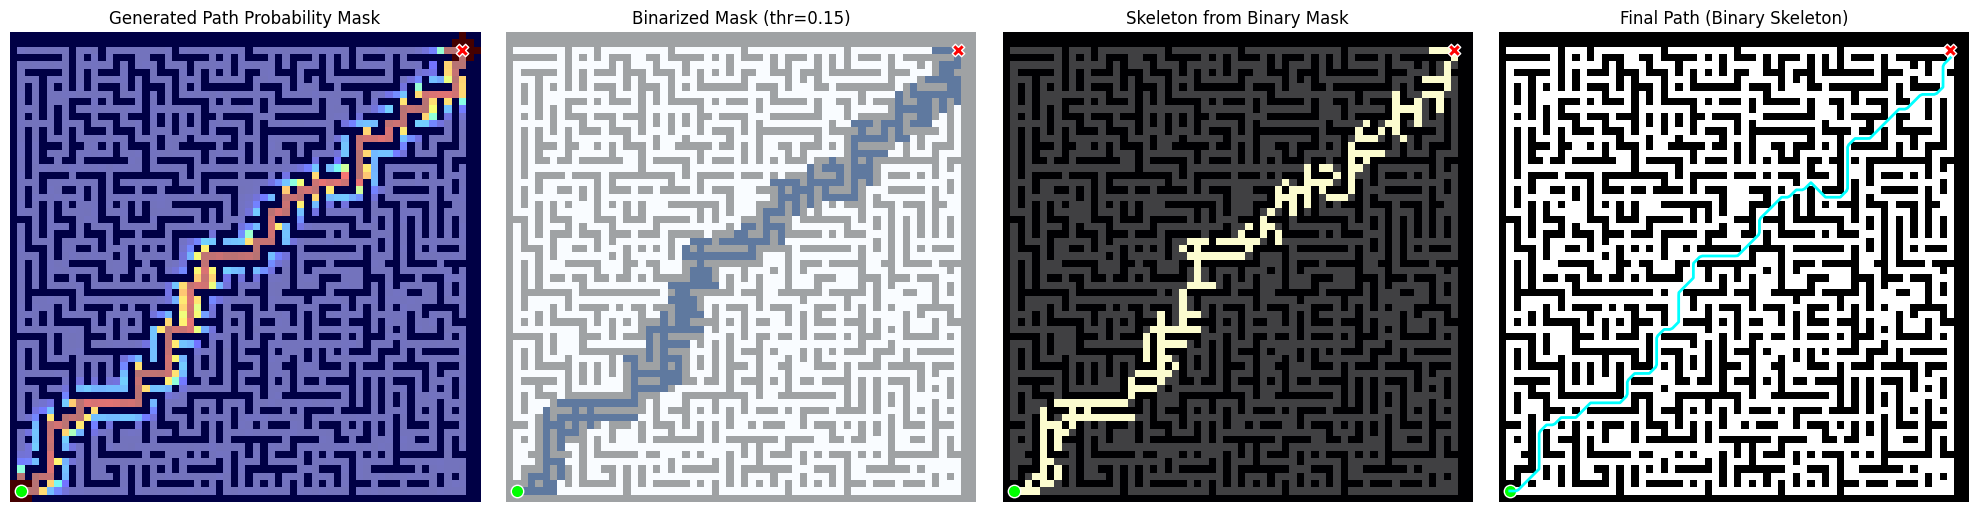

In [67]:
# --- 7. Quick test (Map_0): binary-mask-only skeleton/path extraction ---
test_data = map_dictionary['Map_0']
test_cond = build_cond_from_item(test_data, map_size=IMG_SIZE, sigma=START_GOAL_SIGMA)

prob_mask = generate_path_mask(test_cond).detach().cpu().numpy()      # [64,64]
AUTO_THRESHOLD, mask_bin = select_threshold_by_connectivity(
    prob_mask,
    free_mask=(1.0 - test_data['map'].astype(np.float32)),
    start_rc=test_data['start'],
    goal_rc=test_data['goal'],
    thr_values=THR_CANDIDATES,
    use_lcc=USE_LARGEST_CC,
)

# Use binary-mask route only (prob_mask intentionally not used in extraction).
skel, raw_path, final_path = extract_final_path(
    mask_bin,
    test_data['start'],
    test_data['goal'],
    closing_iter=SKELETON_PRE_CLOSING,
    dilation_iter=SKELETON_PRE_DILATION,
    path_length=PATH_LENGTH,
    prob_mask=None,
    free_mask=(1.0 - test_data['map'].astype(np.float32)),
)

path_ok = final_path is not None
print(f"Step 4 selected threshold (connectivity-first): {AUTO_THRESHOLD:.2f}, use_lcc={USE_LARGEST_CC}")
print(f"Step 6 path found: {path_ok}")
if path_ok:
    print(f"Raw path points: {len(raw_path)} | Resampled path points: {len(final_path)}")

plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.imshow(test_data['map'], cmap='Greys', origin='lower')
plt.imshow(prob_mask, cmap='jet', alpha=0.55, origin='lower')
plt.scatter(test_data['start'][1], test_data['start'][0], c='lime', s=80, marker='o', edgecolors='white')
plt.scatter(test_data['goal'][1], test_data['goal'][0], c='red', s=80, marker='X', edgecolors='white')
plt.title('Generated Path Probability Mask')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(test_data['map'], cmap='Greys', origin='lower')
plt.imshow(mask_bin, cmap='Blues', alpha=0.65, origin='lower')
plt.scatter(test_data['start'][1], test_data['start'][0], c='lime', s=80, marker='o', edgecolors='white')
plt.scatter(test_data['goal'][1], test_data['goal'][0], c='red', s=80, marker='X', edgecolors='white')
plt.title(f'Binarized Mask (thr={AUTO_THRESHOLD:.2f})')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(test_data['map'], cmap='Greys', origin='lower')
plt.imshow(skel.astype(np.float32), cmap='magma', alpha=0.75, origin='lower')
plt.scatter(test_data['start'][1], test_data['start'][0], c='lime', s=80, marker='o', edgecolors='white')
plt.scatter(test_data['goal'][1], test_data['goal'][0], c='red', s=80, marker='X', edgecolors='white')
plt.title('Skeleton from Binary Mask')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(test_data['map'], cmap='Greys', origin='lower')
if path_ok:
    plt.plot(final_path[:, 1], final_path[:, 0], color='cyan', linewidth=2)
    plt.title('Final Path (Binary Skeleton)')
else:
    plt.title('No valid skeleton path found')
plt.scatter(test_data['start'][1], test_data['start'][0], c='lime', s=80, marker='o', edgecolors='white')
plt.scatter(test_data['goal'][1], test_data['goal'][0], c='red', s=80, marker='X', edgecolors='white')
plt.axis('off')

plt.tight_layout()
plt.show()

正在渲染紅色方塊車動畫，共 256 幀，請稍候...
✅ 動畫已成功儲存為：red_car_Map0_diffusion.gif


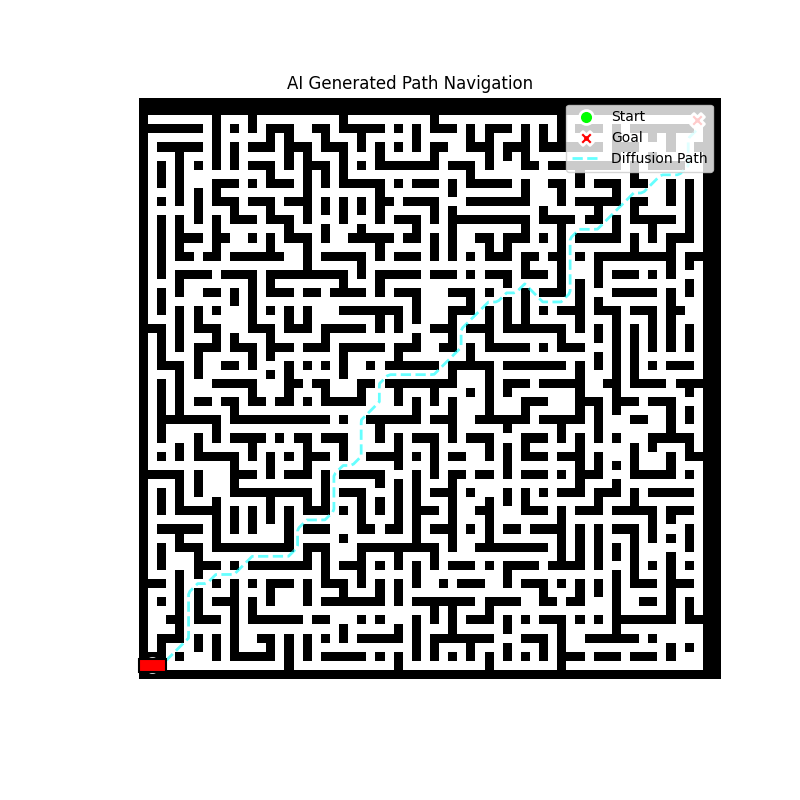

In [68]:
import matplotlib.animation as animation
import matplotlib.patches as patches
import matplotlib.transforms as transforms
from IPython.display import Image, display

# ==========================================
# 8. 生成紅色方塊車輛動畫
# ==========================================
def create_red_car_animation(map_data, start, goal, path_rc, filename="red_car_navigation.gif"):
    if path_rc is None or len(path_rc) < 2:
        print("路徑太短或不存在，無法生成動畫！")
        return

    # 1. 準備畫布與背景
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(map_data, cmap='Greys', origin='lower')
    
    # 畫出起點與終點 (終點原本是紅色，為了跟紅車區分，加上白色粗邊框)
    ax.scatter(start[1], start[0], c='lime', s=100, marker='o', edgecolors='white', linewidths=2, zorder=3, label='Start')
    ax.scatter(goal[1], goal[0], c='red', s=100, marker='X', edgecolors='white', linewidths=2, zorder=3, label='Goal')
    
    # 提取 X, Y 座標 (你的 path 是 [row, col])
    path_y = path_rc[:, 0]
    path_x = path_rc[:, 1]
    
    # 畫出 AI 生成的軌跡參考線
    ax.plot(path_x, path_y, color='cyan', linewidth=2, linestyle='--', alpha=0.6, label='Diffusion Path')

    # 2. 定義「紅色方塊車」
    car_length = 3.0  # 車長
    car_width = 1.5   # 車寬
    # 將中心點設在 (0,0)，方便後續旋轉
    car = patches.Rectangle(
        (-car_length/2, -car_width/2), 
        car_length, car_width, 
        linewidth=1.5, edgecolor='black', facecolor='red', zorder=5 # 改為 facecolor='red'
    )
    ax.add_patch(car)

    ax.set_title("AI Generated Path Navigation")
    ax.legend(loc="upper right")
    ax.axis('off')

    # 3. 定義每一幀的更新動作
    def update(frame):
        cx, cy = path_x[frame], path_y[frame]
        
        # 計算車頭朝向 (θ = arctan2(Δy, Δx))
        if frame < len(path_x) - 1:
            nx, ny = path_x[frame+1], path_y[frame+1]
        else:
            # 最後一幀維持前一個角度
            nx, ny = cx + (cx - path_x[frame-1]), cy + (cy - path_y[frame-1])
            
        angle_rad = np.arctan2(ny - cy, nx - cx)
        angle_deg = np.degrees(angle_rad)
        
        # 建立變換矩陣：旋轉 + 平移
        t = transforms.Affine2D().rotate_deg(angle_deg).translate(cx, cy) + ax.transData
        car.set_transform(t)
        
        return car,

    # 4. 生成並儲存動畫
    print(f"正在渲染紅色方塊車動畫，共 {len(path_x)} 幀，請稍候...")
    ani = animation.FuncAnimation(fig, update, frames=len(path_x), interval=40, blit=True)
    
    # 儲存為 GIF
    ani.save(filename, writer='pillow', fps=25)
    plt.close() # 關閉靜態畫布，避免重複顯示
    print(f"✅ 動畫已成功儲存為：{filename}")

# --- 執行條件檢查與動畫生成 ---
if path_ok:
    gif_filename = f"red_car_Map0_diffusion.gif"
    create_red_car_animation(
        map_data=test_data['map'],
        start=test_data['start'],
        goal=test_data['goal'],
        path_rc=final_path,  # 這是你剛才萃取出來的最終路徑
        filename=gif_filename
    )
    # 在 Jupyter Notebook 中直接顯示出來
    display(Image(filename=gif_filename))
else:
    print("因為沒有找到有效路徑，跳過動畫生成。")

正在渲染智慧調速動畫，共 294 幀，請稍候...
✅ 動畫已成功儲存為：comparison_astar_vs_diffusion_smart.gif


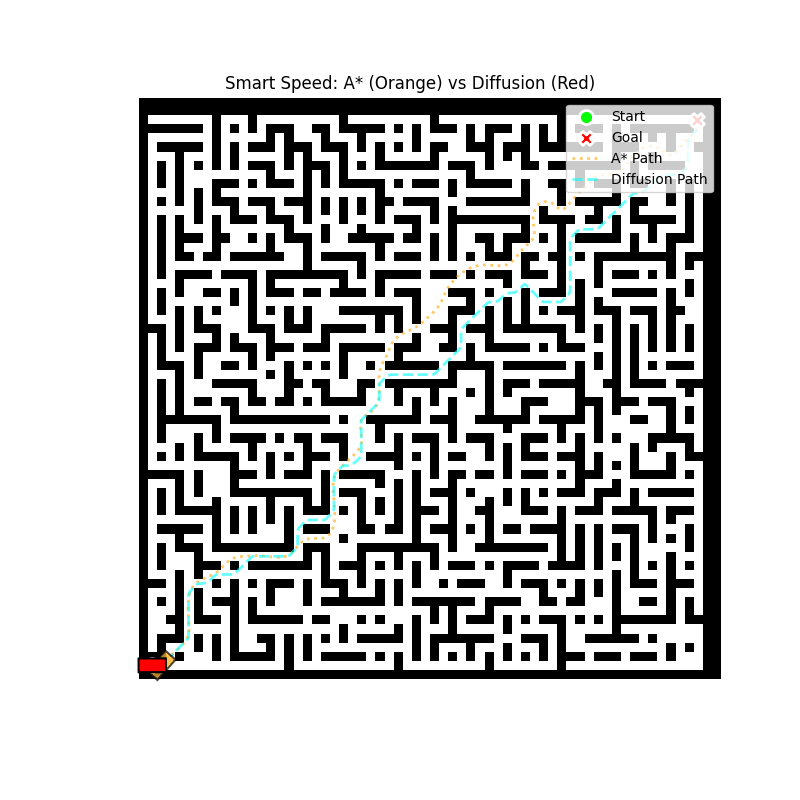

In [69]:
import matplotlib.animation as animation
import matplotlib.patches as patches
import matplotlib.transforms as transforms
from IPython.display import Image, display
import numpy as np

# ==========================================
# 0. 新增：過彎動態減速引擎 (Velocity Profile)
# ==========================================
def resample_path_with_turns(path, base_speed=0.6, turn_speed=0.15, lookahead=15):
    """根據軌跡的彎曲程度（曲率）動態調整車速"""
    path = np.array(path)
    if len(path) < 2: return path
    
    diffs = np.diff(path, axis=0)
    seg_lengths = np.linalg.norm(diffs, axis=1)
    cum_lengths = np.concatenate([[0], np.cumsum(seg_lengths)])
    total_length = cum_lengths[-1]
    
    # 高密度插值
    fine_s = np.linspace(0, total_length, 1000)
    fine_y = np.interp(fine_s, cum_lengths, path[:, 0])
    fine_x = np.interp(fine_s, cum_lengths, path[:, 1])
    fine_path = np.vstack((fine_y, fine_x)).T
    
    # 計算曲率角度
    angles = []
    for i in range(1000):
        p_prev = fine_path[max(0, i - lookahead)]
        p_next = fine_path[min(999, i + lookahead)]
        p_curr = fine_path[i]
        
        v1 = p_curr - p_prev
        v2 = p_next - p_curr
        
        if np.linalg.norm(v1) < 1e-3 or np.linalg.norm(v2) < 1e-3:
            angles.append(0.0)
        else:
            v1_u = v1 / np.linalg.norm(v1)
            v2_u = v2 / np.linalg.norm(v2)
            dot = np.clip(np.dot(v1_u, v2_u), -1.0, 1.0)
            angles.append(np.arccos(dot))
            
    angles = np.array(angles)
    max_angle = np.pi / 4  
    speed_ratio = 1.0 - np.clip(angles / max_angle, 0.0, 1.0)
    speeds = turn_speed + speed_ratio * (base_speed - turn_speed)
    
    # 依動態速度取樣
    new_path = []
    current_s = 0.0
    while current_s < total_length:
        idx = np.searchsorted(fine_s, current_s)
        if idx >= 1000: break
        new_path.append(fine_path[idx])
        current_s += speeds[idx]
        
    new_path.append(fine_path[-1])
    return np.array(new_path)

# ==========================================
# 9. 雙車對決動畫 (A* 橘車 vs Diffusion 紅車)
# ==========================================
def create_comparison_animation(map_data, start, goal, path_astar, path_diff, filename="astar_vs_diffusion_smart.gif"):
    if path_astar is None or path_diff is None or len(path_astar) < 2 or len(path_diff) < 2:
        print("路徑不完整，無法生成比較動畫！")
        return

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(map_data, cmap='Greys', origin='lower')
    
    ax.scatter(start[1], start[0], c='lime', s=100, marker='o', edgecolors='white', linewidths=2, zorder=3, label='Start')
    ax.scatter(goal[1], goal[0], c='red', s=100, marker='X', edgecolors='white', linewidths=2, zorder=3, label='Goal')
    
    astar_y, astar_x = path_astar[:, 0], path_astar[:, 1]
    diff_y, diff_x = path_diff[:, 0], path_diff[:, 1]

    ax.plot(astar_x, astar_y, color='orange', linewidth=2, linestyle=':', alpha=0.6, label='A* Path')
    ax.plot(diff_x, diff_y, color='cyan', linewidth=2, linestyle='--', alpha=0.6, label='Diffusion Path')

    car_length, car_width = 3.0, 1.5
    car_astar = patches.Rectangle((-car_length/2, -car_width/2), car_length, car_width, 
                                  linewidth=1.5, edgecolor='black', facecolor='orange', alpha=0.7, zorder=4)
    car_diff = patches.Rectangle((-car_length/2, -car_width/2), car_length, car_width, 
                                 linewidth=1.5, edgecolor='black', facecolor='red', zorder=5)
    
    ax.add_patch(car_astar)
    ax.add_patch(car_diff)

    ax.set_title("Smart Speed: A* (Orange) vs Diffusion (Red)")
    ax.legend(loc="upper right")
    ax.axis('off')

    # ⭐ 升級：允許兩台車長度不同，先到的車子會停在終點
    def get_transform(x_array, y_array, frame, ax_obj):
        # 如果這台車已經跑完了，就讓它停在最後一個點
        idx = min(frame, len(x_array) - 1)
        cx, cy = x_array[idx], y_array[idx]
        
        # 確保朝向正確
        if idx < len(x_array) - 1:
            nx, ny = x_array[idx+1], y_array[idx+1]
        else:
            nx, ny = cx + (cx - x_array[idx-1]), cy + (cy - y_array[idx-1])
            
        angle_rad = np.arctan2(ny - cy, nx - cx)
        angle_deg = np.degrees(angle_rad)
        return transforms.Affine2D().rotate_deg(angle_deg).translate(cx, cy) + ax_obj.transData

    def update(frame):
        car_astar.set_transform(get_transform(astar_x, astar_y, frame, ax))
        car_diff.set_transform(get_transform(diff_x, diff_y, frame, ax))
        return car_astar, car_diff

    # ⭐ 升級：取最長的幀數，讓兩台車都能抵達終點
    frames_count = max(len(astar_x), len(diff_x))
    print(f"正在渲染智慧調速動畫，共 {frames_count} 幀，請稍候...")
    
    ani = animation.FuncAnimation(fig, update, frames=frames_count, interval=40, blit=True)
    ani.save(filename, writer='pillow', fps=25)
    plt.close()
    print(f"✅ 動畫已成功儲存為：{filename}")

# --- 執行雙車對決動畫 ---
if path_ok and test_data['smooth_path'] is not None:
    gif_filename = "comparison_astar_vs_diffusion_smart.gif"
    
    # 1. 取得原始路徑
    raw_astar = np.asarray(test_data['smooth_path'], dtype=np.float32)
    raw_diff = final_path
    
    # ⭐ 2. 套用轉彎減速演算法
    # base_speed 是直線最高速，turn_speed 是過彎最低速
    smart_astar = resample_path_with_turns(raw_astar, base_speed=0.8, turn_speed=0.15)
    smart_diff  = resample_path_with_turns(raw_diff, base_speed=0.8, turn_speed=0.15)
    
    # 3. 呼叫動畫生成函數
    create_comparison_animation(
        map_data=test_data['map'],
        start=test_data['start'],
        goal=test_data['goal'],
        path_astar=smart_astar, 
        path_diff=smart_diff,   
        filename=gif_filename
    )
    
    # 在 Jupyter Notebook 中直接顯示出來
    display(Image(filename=gif_filename))
else:
    print("路徑資料不齊全 (可能 A* 沒找到路徑 或 Diffusion 萃取失敗)，跳過對決動畫生成。")

Unseen map threshold=0.30, use_lcc=False
Step 6 path found: True
Raw path points: 87 | Resampled path points: 256
Final output format: (row, col), shape=(256, 2)


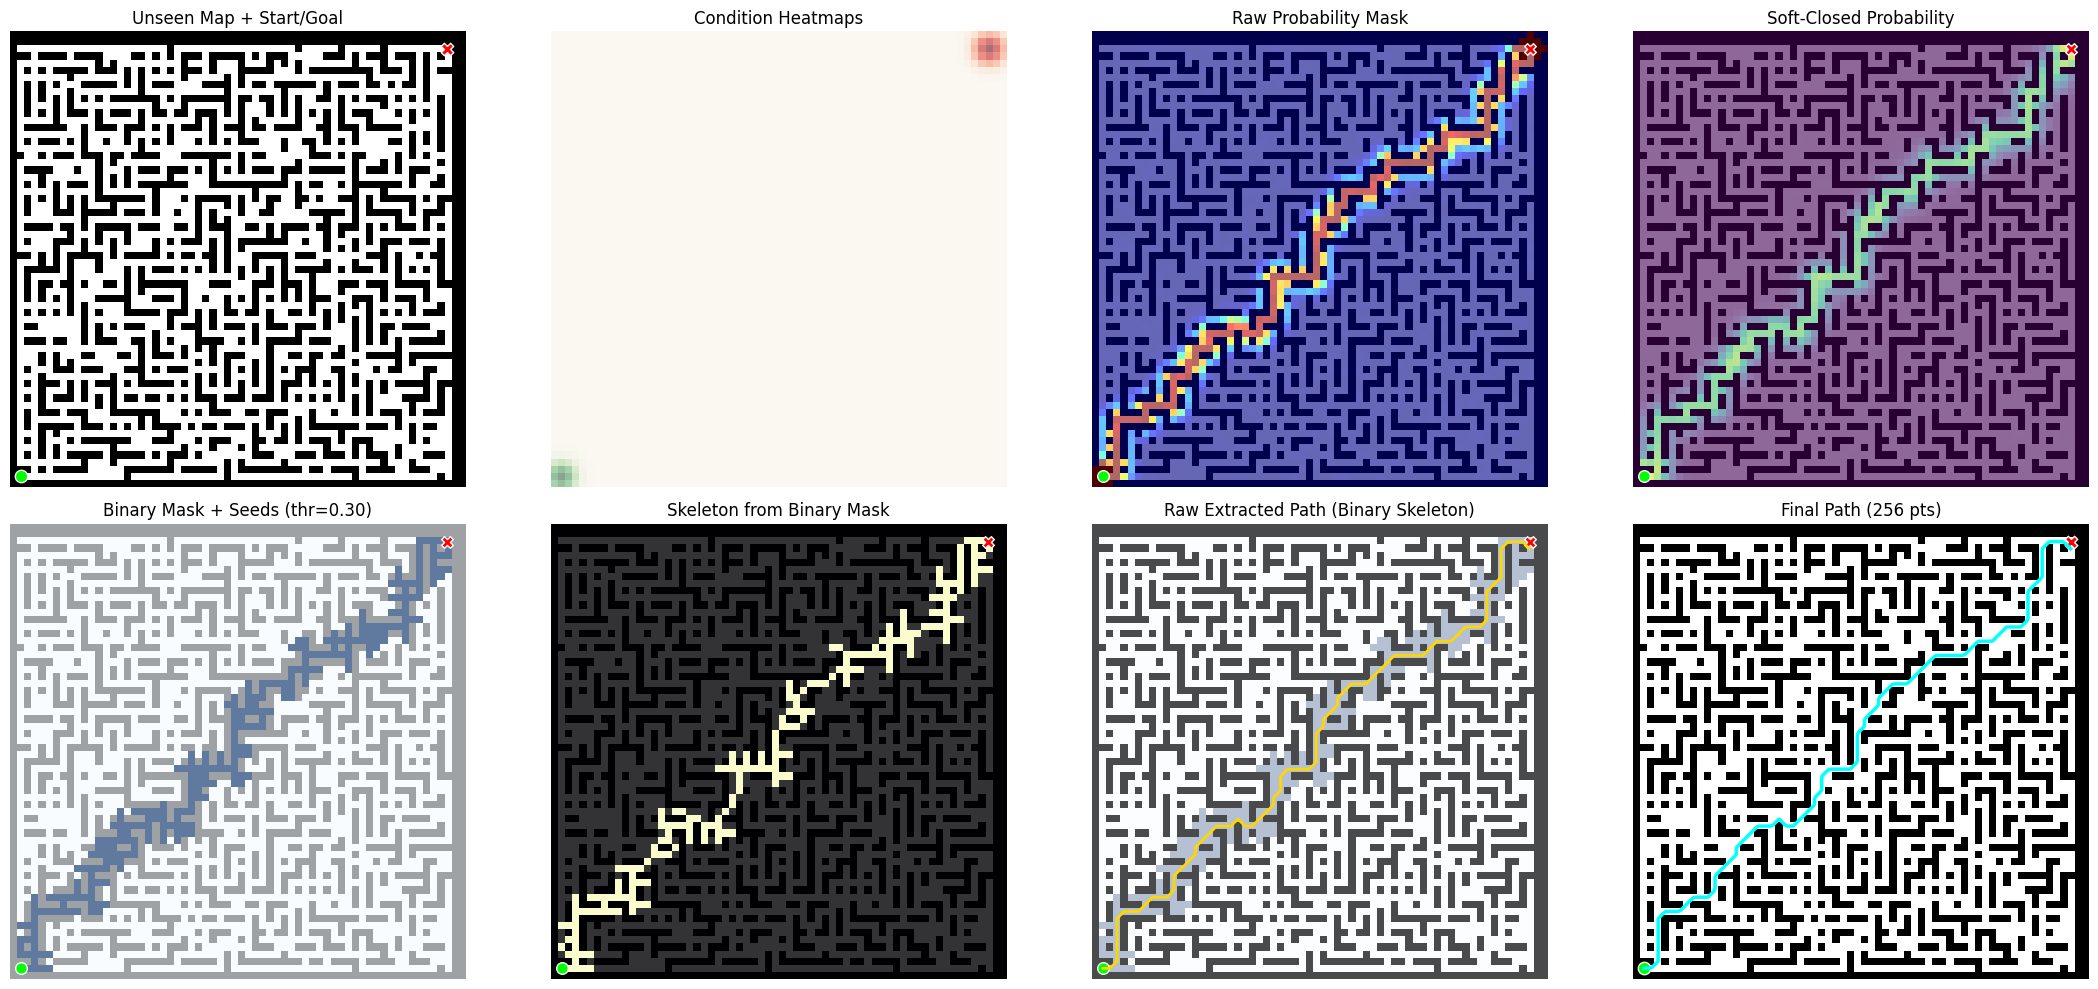

In [71]:
# 1. Generate one unseen map
# test_grid, test_start, test_goal = generate_map(size=64)

# Change these lines in Cell 5:
test_grid, test_start, test_goal = generate_map(size=IMG_SIZE, multiplier=1)

start_hm = gaussian_heatmap(test_grid.shape, test_start, sigma=START_GOAL_SIGMA)
goal_hm = gaussian_heatmap(test_grid.shape, test_goal, sigma=START_GOAL_SIGMA)

# 2. Build 3-channel condition: [occ, start_hm, goal_hm]
occ = test_grid.astype(np.float32)
cond = np.stack([occ, start_hm, goal_hm], axis=0).astype(np.float32)
test_cond = torch.from_numpy(cond).unsqueeze(0)  # [1,3,64,64]

# 3. Diffusion generates path probability mask
denoise_model.eval()
with torch.no_grad():
    prob_mask = generate_path_mask(test_cond).cpu().numpy()  # [64,64]

# 4. Step 4 postprocess: connectivity-first threshold + endpoint-connected CC
thr_to_use, mask_bin = select_threshold_by_connectivity(
    prob_mask,
    free_mask=(1.0 - occ),
    start_rc=test_start,
    goal_rc=test_goal,
    thr_values=THR_CANDIDATES,
    use_lcc=USE_LARGEST_CC,
)

# 5/6/7: binary-mask-only skeletonization -> shortest path -> fixed-length resample
skel, raw_path, final_path = extract_final_path(
    mask_bin,
    test_start,
    test_goal,
    closing_iter=SKELETON_PRE_CLOSING,
    dilation_iter=SKELETON_PRE_DILATION,
    path_length=PATH_LENGTH,
    prob_mask=None,
    free_mask=(1.0 - occ),
)

path_ok = final_path is not None
print(f"Unseen map threshold={thr_to_use:.2f}, use_lcc={USE_LARGEST_CC}")
print(f"Step 6 path found: {path_ok}")
if path_ok:
    print(f"Raw path points: {len(raw_path)} | Resampled path points: {len(final_path)}")
    print(f"Final output format: (row, col), shape={final_path.shape}")

prob_soft = soft_close_probability_mask(
    prob_mask,
    free_mask=(1.0 - occ),
    sigma=SOFT_CLOSE_SIGMA,
    blend=SOFT_CLOSE_WEIGHT,
 )
endpoint_seed = np.logical_or(
    _disk_mask_numpy(test_grid.shape, test_start, POSTPROC_ENDPOINT_SEED_RADIUS),
    _disk_mask_numpy(test_grid.shape, test_goal, POSTPROC_ENDPOINT_SEED_RADIUS),
).astype(np.float32)
endpoint_seed = endpoint_seed * (1.0 - occ)
mask_with_seed = np.maximum(mask_bin, endpoint_seed)

# 6. Visualization
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.ravel()

axes[0].imshow(test_grid, cmap='Greys', origin='lower')
axes[0].scatter(test_start[1], test_start[0], c='lime', s=80, marker='o', edgecolors='white')
axes[0].scatter(test_goal[1], test_goal[0], c='red', s=80, marker='X', edgecolors='white')
axes[0].set_title('Unseen Map + Start/Goal')
axes[0].axis('off')

axes[1].imshow(start_hm, cmap='Greens', origin='lower')
axes[1].imshow(goal_hm, cmap='Reds', alpha=0.55, origin='lower')
axes[1].set_title('Condition Heatmaps')
axes[1].axis('off')

axes[2].imshow(test_grid, cmap='Greys', origin='lower')
axes[2].imshow(prob_mask, cmap='jet', alpha=0.60, origin='lower', vmin=0.0, vmax=1.0)
axes[2].scatter(test_start[1], test_start[0], c='lime', s=70, marker='o', edgecolors='white')
axes[2].scatter(test_goal[1], test_goal[0], c='red', s=70, marker='X', edgecolors='white')
axes[2].set_title('Raw Probability Mask')
axes[2].axis('off')

axes[3].imshow(test_grid, cmap='Greys', origin='lower')
axes[3].imshow(prob_soft, cmap='viridis', alpha=0.60, origin='lower', vmin=0.0, vmax=1.0)
axes[3].scatter(test_start[1], test_start[0], c='lime', s=70, marker='o', edgecolors='white')
axes[3].scatter(test_goal[1], test_goal[0], c='red', s=70, marker='X', edgecolors='white')
axes[3].set_title('Soft-Closed Probability')
axes[3].axis('off')

axes[4].imshow(test_grid, cmap='Greys', origin='lower')
axes[4].imshow(mask_with_seed, cmap='Blues', alpha=0.65, origin='lower')
axes[4].scatter(test_start[1], test_start[0], c='lime', s=70, marker='o', edgecolors='white')
axes[4].scatter(test_goal[1], test_goal[0], c='red', s=70, marker='X', edgecolors='white')
axes[4].set_title(f'Binary Mask + Seeds (thr={thr_to_use:.2f})')
axes[4].axis('off')

axes[5].imshow(test_grid, cmap='Greys', origin='lower')
axes[5].imshow(skel.astype(np.float32), cmap='magma', alpha=0.80, origin='lower')
axes[5].scatter(test_start[1], test_start[0], c='lime', s=70, marker='o', edgecolors='white')
axes[5].scatter(test_goal[1], test_goal[0], c='red', s=70, marker='X', edgecolors='white')
axes[5].set_title('Skeleton from Binary Mask')
axes[5].axis('off')

axes[6].imshow(test_grid, cmap='Greys', origin='lower')
axes[6].imshow(mask_bin, cmap='Blues', alpha=0.30, origin='lower')
if raw_path is not None:
    axes[6].plot(raw_path[:, 1], raw_path[:, 0], color='gold', linewidth=2)
axes[6].scatter(test_start[1], test_start[0], c='lime', s=70, marker='o', edgecolors='white')
axes[6].scatter(test_goal[1], test_goal[0], c='red', s=70, marker='X', edgecolors='white')
axes[6].set_title('Raw Extracted Path (Binary Skeleton)')
axes[6].axis('off')

axes[7].imshow(test_grid, cmap='Greys', origin='lower')
if path_ok:
    axes[7].plot(final_path[:, 1], final_path[:, 0], color='cyan', linewidth=2.5, label='final path')
    axes[7].set_title(f'Final Path ({PATH_LENGTH} pts)')
else:
    axes[7].set_title('No Valid Final Path')
axes[7].scatter(test_start[1], test_start[0], c='lime', s=80, marker='o', edgecolors='white')
axes[7].scatter(test_goal[1], test_goal[0], c='red', s=80, marker='X', edgecolors='white')
axes[7].axis('off')

plt.tight_layout()
plt.show()

# final_path is Step 7 output: ndarray, shape [PATH_LENGTH, 2], each row=(row, col)


開始為這張新地圖計算 A* 基準軌跡...
✅ A* 路徑計算與平滑完成！
正在渲染智慧調速動畫，共 282 幀，請稍候...
✅ 動畫已成功儲存為：unseen_map_astar_vs_diffusion.gif


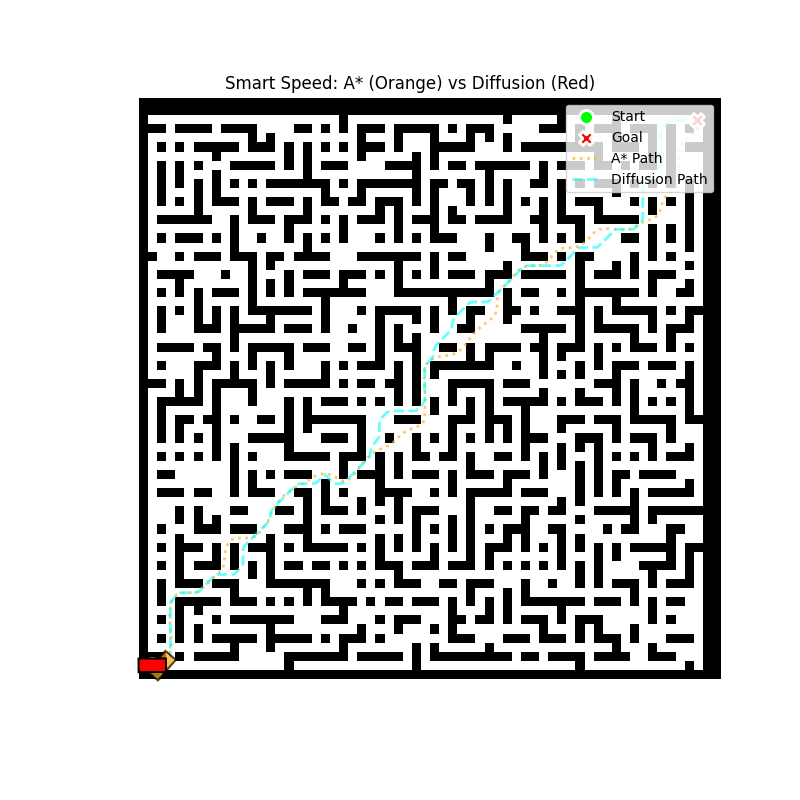

In [72]:
# ==========================================
# 8. 為 Unseen Map 生成 A* 路徑並製作比較動畫
# ==========================================
from IPython.display import Image, display

print("\n開始為這張新地圖計算 A* 基準軌跡...")
# 1. 幫這張新地圖跑傳統的 A* 演算法當作對照組
astar_path_raw = a_star(test_grid, test_start, test_goal)

if astar_path_raw is not None and len(astar_path_raw) >= 4:
    # 套用 B-spline 平滑，取 128 個點
    astar_smooth = B_spline(astar_path_raw, s=1, k=3, num_points=128)
    print("✅ A* 路徑計算與平滑完成！")
else:
    astar_smooth = None
    print("❌ A* 找不到路徑或路徑太短。")

# 2. 呼叫雙車對決動畫 (確認你的環境中已經有剛剛定義的 resample_path_with_turns 和 create_comparison_animation 函數)
if path_ok and astar_smooth is not None:
    gif_filename = "unseen_map_astar_vs_diffusion.gif"
    
    # 將兩條軌跡套用「轉彎動態減速引擎」
    # (base_speed: 直線最高速, turn_speed: 過彎最低速)
    smart_astar = resample_path_with_turns(astar_smooth, base_speed=0.8, turn_speed=0.15)
    smart_diff  = resample_path_with_turns(final_path, base_speed=0.8, turn_speed=0.15)
    
    # 產生動畫
    create_comparison_animation(
        map_data=test_grid,        # 注意：這裡是 test_grid
        start=test_start,          # 注意：這裡是 test_start
        goal=test_goal,            # 注意：這裡是 test_goal
        path_astar=smart_astar, 
        path_diff=smart_diff,   
        filename=gif_filename
    )
    
    # 在 Jupyter Notebook 中直接顯示出來
    display(Image(filename=gif_filename))
else:
    print("路徑不完整 (可能 A* 沒找到路徑 或 Diffusion 萃取失敗)，跳過對決動畫生成。")

Unseen map V2 (center 6x6 blocked) threshold=0.60, use_lcc=False
Step 6 path found: True
Raw path points: 91 | Resampled path points: 256
Final output format: (row, col), shape=(256, 2)


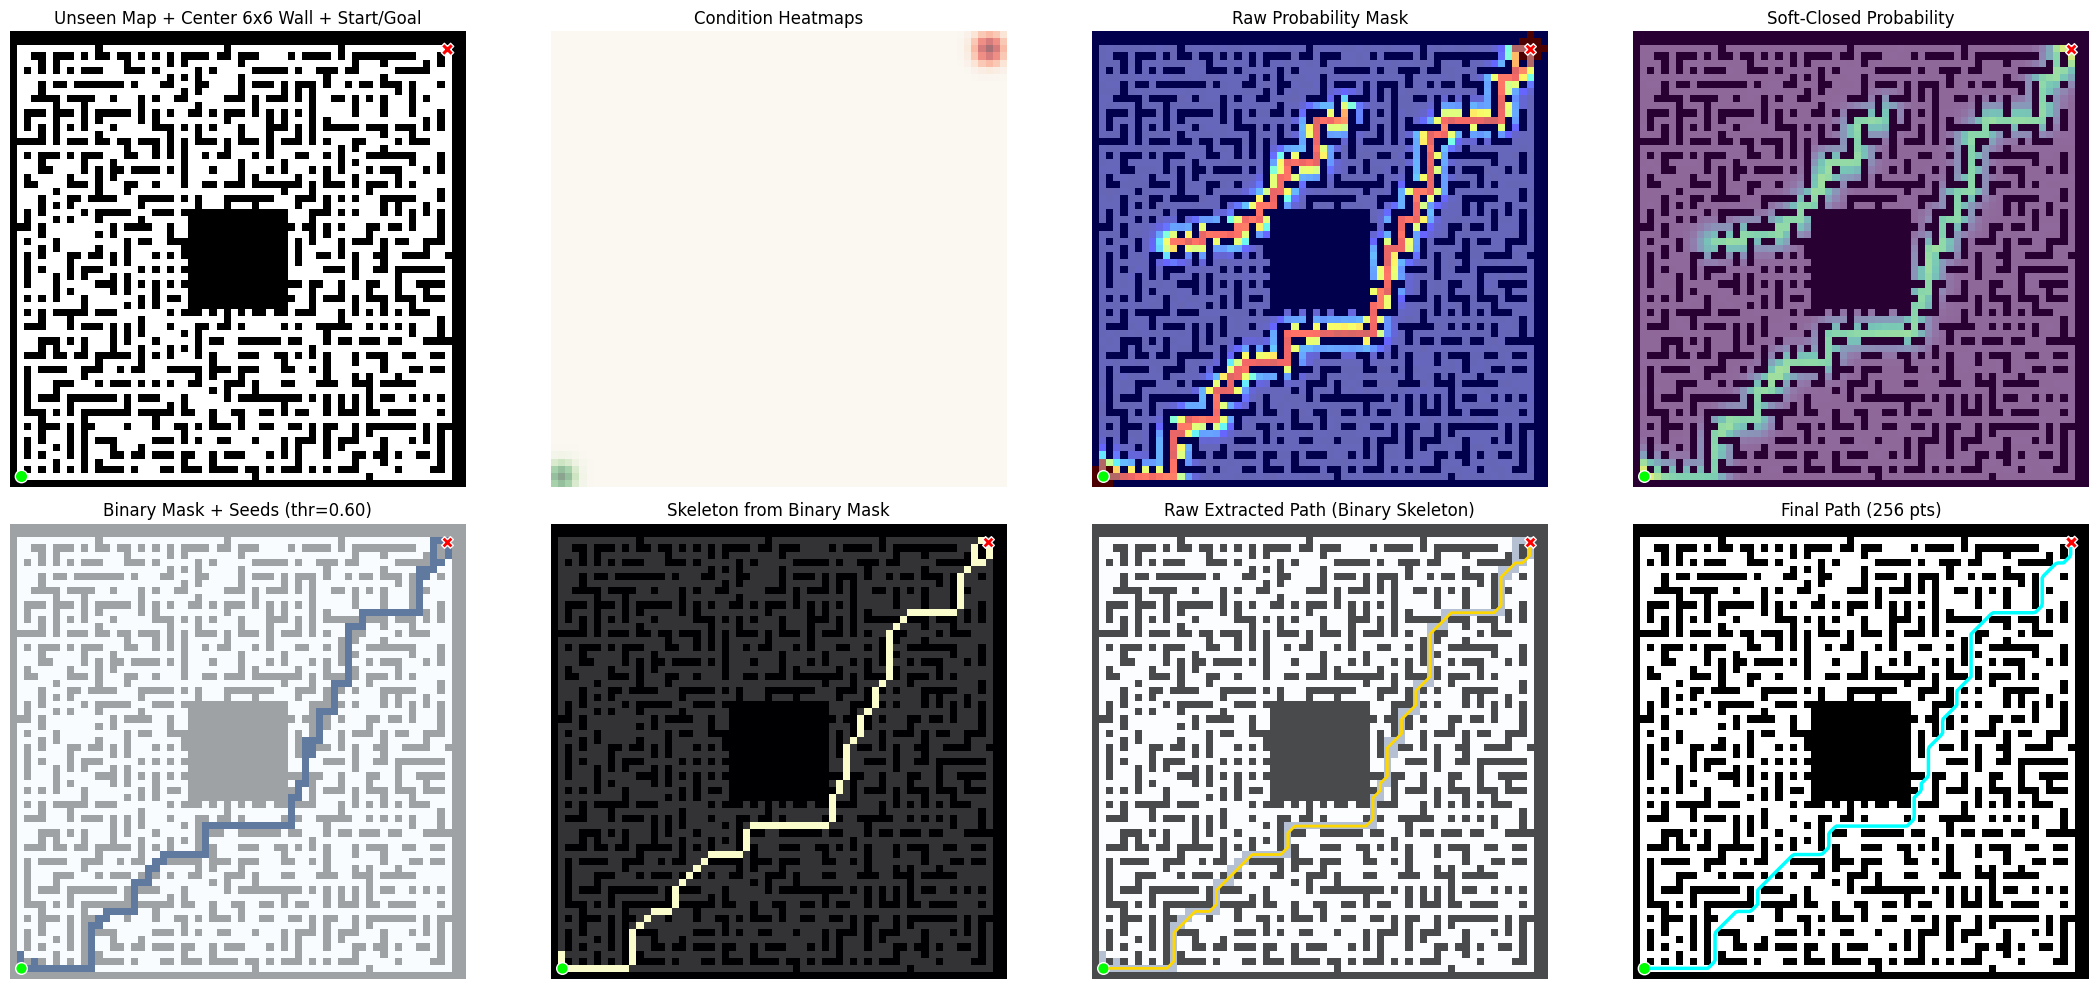

In [78]:
# --- Unseen Map Inference (Version 2: center 6x6 blocked) ---
# Same inference flow as Cell 8, with an extra forced obstacle in map center.

CENTER_BLOCK_SIZE = 15

# 1. Generate one unseen map
test_grid, test_start, test_goal = generate_map(size=IMG_SIZE, multiplier=1, loop_prob=0.4)

# Force center 6x6 wall block
center = IMG_SIZE // 2
half = CENTER_BLOCK_SIZE // 2
r0, r1 = center - half, center + half
c0, c1 = center - half, center + half
test_grid[r0:r1, c0:c1] = 1.0

# Keep start/goal free in case they lie in the blocked area
test_grid[test_start[0], test_start[1]] = 0.0
test_grid[test_goal[0], test_goal[1]] = 0.0

start_hm = gaussian_heatmap(test_grid.shape, test_start, sigma=START_GOAL_SIGMA)
goal_hm = gaussian_heatmap(test_grid.shape, test_goal, sigma=START_GOAL_SIGMA)

# 2. Build 3-channel condition: [occ, start_hm, goal_hm]
occ = test_grid.astype(np.float32)
cond = np.stack([occ, start_hm, goal_hm], axis=0).astype(np.float32)
test_cond = torch.from_numpy(cond).unsqueeze(0)

# 3. Diffusion generates path probability mask
denoise_model.eval()
with torch.no_grad():
    prob_mask = generate_path_mask(test_cond).cpu().numpy()

# 4. Postprocess: connectivity-first threshold
thr_to_use, mask_bin = select_threshold_by_connectivity(
    prob_mask,
    free_mask=(1.0 - occ),
    start_rc=test_start,
    goal_rc=test_goal,
    thr_values=THR_CANDIDATES,
    use_lcc=USE_LARGEST_CC,
)

# 5/6/7: skeleton path extraction from binary mask
skel, raw_path, final_path = extract_final_path(
    mask_bin,
    test_start,
    test_goal,
    closing_iter=SKELETON_PRE_CLOSING,
    dilation_iter=SKELETON_PRE_DILATION,
    path_length=PATH_LENGTH,
    prob_mask=None,
    free_mask=(1.0 - occ),
)

path_ok = final_path is not None
print(f"Unseen map V2 (center 6x6 blocked) threshold={thr_to_use:.2f}, use_lcc={USE_LARGEST_CC}")
print(f"Step 6 path found: {path_ok}")
if path_ok:
    print(f"Raw path points: {len(raw_path)} | Resampled path points: {len(final_path)}")
    print(f"Final output format: (row, col), shape={final_path.shape}")

prob_soft = soft_close_probability_mask(
    prob_mask,
    free_mask=(1.0 - occ),
    sigma=SOFT_CLOSE_SIGMA,
    blend=SOFT_CLOSE_WEIGHT,
)
endpoint_seed = np.logical_or(
    _disk_mask_numpy(test_grid.shape, test_start, POSTPROC_ENDPOINT_SEED_RADIUS),
    _disk_mask_numpy(test_grid.shape, test_goal, POSTPROC_ENDPOINT_SEED_RADIUS),
).astype(np.float32)
endpoint_seed = endpoint_seed * (1.0 - occ)
mask_with_seed = np.maximum(mask_bin, endpoint_seed)

# 6. Visualization (same layout as Cell 8)
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.ravel()

axes[0].imshow(test_grid, cmap='Greys', origin='lower')
axes[0].scatter(test_start[1], test_start[0], c='lime', s=80, marker='o', edgecolors='white')
axes[0].scatter(test_goal[1], test_goal[0], c='red', s=80, marker='X', edgecolors='white')
axes[0].set_title('Unseen Map + Center 6x6 Wall + Start/Goal')
axes[0].axis('off')

axes[1].imshow(start_hm, cmap='Greens', origin='lower')
axes[1].imshow(goal_hm, cmap='Reds', alpha=0.55, origin='lower')
axes[1].set_title('Condition Heatmaps')
axes[1].axis('off')

axes[2].imshow(test_grid, cmap='Greys', origin='lower')
axes[2].imshow(prob_mask, cmap='jet', alpha=0.60, origin='lower', vmin=0.0, vmax=1.0)
axes[2].scatter(test_start[1], test_start[0], c='lime', s=70, marker='o', edgecolors='white')
axes[2].scatter(test_goal[1], test_goal[0], c='red', s=70, marker='X', edgecolors='white')
axes[2].set_title('Raw Probability Mask')
axes[2].axis('off')

axes[3].imshow(test_grid, cmap='Greys', origin='lower')
axes[3].imshow(prob_soft, cmap='viridis', alpha=0.60, origin='lower', vmin=0.0, vmax=1.0)
axes[3].scatter(test_start[1], test_start[0], c='lime', s=70, marker='o', edgecolors='white')
axes[3].scatter(test_goal[1], test_goal[0], c='red', s=70, marker='X', edgecolors='white')
axes[3].set_title('Soft-Closed Probability')
axes[3].axis('off')

axes[4].imshow(test_grid, cmap='Greys', origin='lower')
axes[4].imshow(mask_with_seed, cmap='Blues', alpha=0.65, origin='lower')
axes[4].scatter(test_start[1], test_start[0], c='lime', s=70, marker='o', edgecolors='white')
axes[4].scatter(test_goal[1], test_goal[0], c='red', s=70, marker='X', edgecolors='white')
axes[4].set_title(f'Binary Mask + Seeds (thr={thr_to_use:.2f})')
axes[4].axis('off')

axes[5].imshow(test_grid, cmap='Greys', origin='lower')
axes[5].imshow(skel.astype(np.float32), cmap='magma', alpha=0.80, origin='lower')
axes[5].scatter(test_start[1], test_start[0], c='lime', s=70, marker='o', edgecolors='white')
axes[5].scatter(test_goal[1], test_goal[0], c='red', s=70, marker='X', edgecolors='white')
axes[5].set_title('Skeleton from Binary Mask')
axes[5].axis('off')

axes[6].imshow(test_grid, cmap='Greys', origin='lower')
axes[6].imshow(mask_bin, cmap='Blues', alpha=0.30, origin='lower')
if raw_path is not None:
    axes[6].plot(raw_path[:, 1], raw_path[:, 0], color='gold', linewidth=2)
axes[6].scatter(test_start[1], test_start[0], c='lime', s=70, marker='o', edgecolors='white')
axes[6].scatter(test_goal[1], test_goal[0], c='red', s=70, marker='X', edgecolors='white')
axes[6].set_title('Raw Extracted Path (Binary Skeleton)')
axes[6].axis('off')

axes[7].imshow(test_grid, cmap='Greys', origin='lower')
if path_ok:
    axes[7].plot(final_path[:, 1], final_path[:, 0], color='cyan', linewidth=2.5, label='final path')
    axes[7].set_title(f'Final Path ({PATH_LENGTH} pts)')
else:
    axes[7].set_title('No Valid Final Path')
axes[7].scatter(test_start[1], test_start[0], c='lime', s=80, marker='o', edgecolors='white')
axes[7].scatter(test_goal[1], test_goal[0], c='red', s=80, marker='X', edgecolors='white')
axes[7].axis('off')

plt.tight_layout()
plt.show()



開始為這張「有中央障礙物」的新地圖計算 A* 基準軌跡...
✅ A* 路徑計算與平滑完成！
正在渲染智慧調速動畫，共 256 幀，請稍候...
✅ 動畫已成功儲存為：center_wall_astar_vs_diffusion.gif


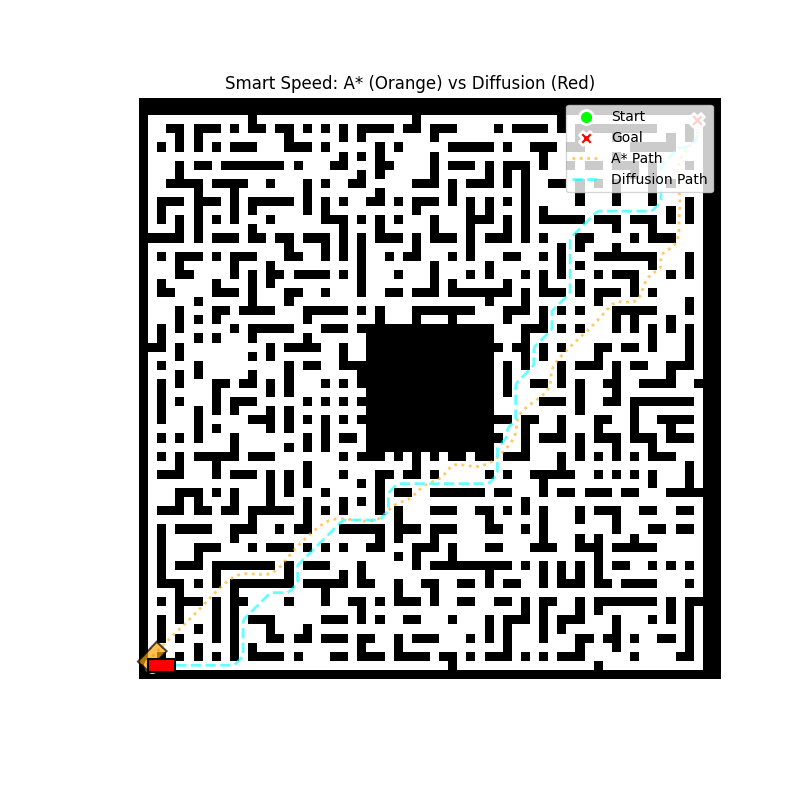

In [79]:
# ==========================================
# 8. 為 Center Wall 版本生成 A* 路徑並製作比較動畫
# ==========================================
from IPython.display import Image, display

print("\n開始為這張「有中央障礙物」的新地圖計算 A* 基準軌跡...")
# 1. 幫這張新地圖跑傳統的 A* 演算法當作對照組
astar_path_raw = a_star(test_grid, test_start, test_goal)

if astar_path_raw is not None and len(astar_path_raw) >= 4:
    # 套用 B-spline 平滑，取 128 個點
    astar_smooth = B_spline(astar_path_raw, s=1, k=3, num_points=128)
    print("✅ A* 路徑計算與平滑完成！")
else:
    astar_smooth = None
    print("❌ A* 找不到路徑或路徑太短。")

# 2. 呼叫雙車對決動畫 (確認環境中已經有 resample_path_with_turns 和 create_comparison_animation)
if path_ok and astar_smooth is not None:
    gif_filename = "center_wall_astar_vs_diffusion.gif"
    
    # 將兩條軌跡套用「轉彎動態減速引擎」
    smart_astar = resample_path_with_turns(astar_smooth, base_speed=0.8, turn_speed=0.15)
    smart_diff  = resample_path_with_turns(final_path, base_speed=0.8, turn_speed=0.15)
    
    # 產生動畫
    create_comparison_animation(
        map_data=test_grid,        # 加入中央障礙物的地圖
        start=test_start,          
        goal=test_goal,            
        path_astar=smart_astar, 
        path_diff=smart_diff,   
        filename=gif_filename
    )
    
    # 在 Jupyter Notebook 中直接顯示出來
    display(Image(filename=gif_filename))
else:
    print("路徑不完整 (可能 A* 沒找到路徑 或 Diffusion 萃取失敗)，跳過對決動畫生成。")

In [49]:
# --- Step 8: Evaluation on unseen maps ---
# Metrics: success/connectivity, collision, path length, endpoint error, threshold sensitivity

EVAL_MAPS = 100
OBSTACLE_PROB = 0.2
END_DIST_THR = 3.0  # pixels


def path_collision_rate(path_rc, occ_grid):
    if path_rc is None or len(path_rc) == 0:
        return np.nan

    h, w = occ_grid.shape
    rr = np.clip(np.round(path_rc[:, 0]).astype(int), 0, h - 1)
    cc = np.clip(np.round(path_rc[:, 1]).astype(int), 0, w - 1)

    collided = occ_grid[rr, cc] > 0.5
    return float(collided.mean())


def path_length_pixels(path_rc):
    if path_rc is None or len(path_rc) < 2:
        return np.nan
    seg = np.diff(path_rc, axis=0)
    return float(np.linalg.norm(seg, axis=1).sum())


def endpoint_errors(path_rc, start_rc, goal_rc):
    if path_rc is None or len(path_rc) == 0:
        return np.nan, np.nan
    p0 = path_rc[0]
    p1 = path_rc[-1]
    e_start = float(np.linalg.norm(p0 - np.array(start_rc, dtype=np.float32)))
    e_goal = float(np.linalg.norm(p1 - np.array(goal_rc, dtype=np.float32)))
    return e_start, e_goal


def evaluate_one_map(grid, start, goal, threshold=None, use_lcc=True):
    cond = np.stack([
        grid.astype(np.float32),
        gaussian_heatmap((IMG_SIZE, IMG_SIZE), start, sigma=START_GOAL_SIGMA),
        gaussian_heatmap((IMG_SIZE, IMG_SIZE), goal, sigma=START_GOAL_SIGMA),
    ], axis=0).astype(np.float32)
    cond_tensor = torch.from_numpy(cond).unsqueeze(0)

    with torch.no_grad():
        prob_mask = generate_path_mask(cond_tensor).cpu().numpy()

    if threshold is None:
        threshold_used, mask_bin = select_threshold_by_connectivity(
            prob_mask,
            free_mask=(1.0 - grid.astype(np.float32)),
            start_rc=start,
            goal_rc=goal,
            thr_values=THR_CANDIDATES,
            use_lcc=use_lcc,
        )
    else:
        threshold_used = float(threshold)
        mask_bin = postprocess_mask(prob_mask, free_mask=(1.0 - grid.astype(np.float32)), thr=threshold_used, use_lcc=use_lcc, start_rc=start, goal_rc=goal)
    skel, raw_path, final_path = extract_final_path(
        mask_bin,
        start,
        goal,
        closing_iter=SKELETON_PRE_CLOSING,
        dilation_iter=SKELETON_PRE_DILATION,
        path_length=PATH_LENGTH,
        prob_mask=prob_mask,
        free_mask=(1.0 - grid.astype(np.float32)),
    )

    ok = final_path is not None
    coll = path_collision_rate(final_path, grid)
    plen = path_length_pixels(final_path)
    e_start, e_goal = endpoint_errors(final_path, start, goal)

    connected = bool(ok and e_start <= END_DIST_THR and e_goal <= END_DIST_THR)

    return {
        'ok': ok,
        'connected': connected,
        'collision_rate': coll,
        'path_length': plen,
        'endpoint_start_err': e_start,
        'endpoint_goal_err': e_goal,
        'prob_mask': prob_mask,
        'mask_bin': mask_bin,
        'skel': skel,
        'final_path': final_path,
        'threshold_used': threshold_used,
    }


thr_eval = None
print(f"Running Step 8 evaluation on {EVAL_MAPS} unseen maps | threshold=auto-connectivity")

ok_list = []
connected_list = []
coll_list = []
len_list = []
start_err_list = []
goal_err_list = []

# threshold sensitivity: fixed threshold vs per-map best threshold
fixed_ok = 0
best_ok = 0

for i in range(EVAL_MAPS):
    grid, start, goal = generate_map(size=IMG_SIZE)

    # fixed-threshold evaluation
    out_fixed = evaluate_one_map(grid, start, goal, threshold=thr_eval, use_lcc=USE_LARGEST_CC)
    ok_list.append(out_fixed['ok'])
    connected_list.append(out_fixed['connected'])
    coll_list.append(out_fixed['collision_rate'])
    len_list.append(out_fixed['path_length'])
    start_err_list.append(out_fixed['endpoint_start_err'])
    goal_err_list.append(out_fixed['endpoint_goal_err'])

    fixed_ok += int(out_fixed['ok'])

    # per-map threshold best (using soft GT from A*+smooth as reference)
    # if no A* path exists, fallback to fixed threshold counting
    path = a_star(grid, start, goal)
    if path is not None and len(path) >= 4:
        smooth = B_spline(path, s=1, k=3, num_points=128)
        item_tmp = {'map': grid, 'start': start, 'goal': goal, 'smooth_path': smooth}
        gt_soft = build_soft_mask_from_item(item_tmp, map_size=IMG_SIZE, path_sigma=PATH_BRUSH_SIGMA)
        best_thr, _, _ = sweep_threshold(out_fixed['prob_mask'], gt_soft, free_mask=(1.0 - grid.astype(np.float32)), start_rc=start, goal_rc=goal, thr_values=THR_CANDIDATES, use_lcc=USE_LARGEST_CC)
        out_best = evaluate_one_map(grid, start, goal, threshold=best_thr, use_lcc=USE_LARGEST_CC)
        best_ok += int(out_best['ok'])
    else:
        best_ok += int(out_fixed['ok'])

ok_arr = np.array(ok_list, dtype=np.float32)
connected_arr = np.array(connected_list, dtype=np.float32)
coll_arr = np.array([x for x in coll_list if not np.isnan(x)], dtype=np.float32)
len_arr = np.array([x for x in len_list if not np.isnan(x)], dtype=np.float32)
se_arr = np.array([x for x in start_err_list if not np.isnan(x)], dtype=np.float32)
ge_arr = np.array([x for x in goal_err_list if not np.isnan(x)], dtype=np.float32)

print("\n===== Step 8 Summary =====")
print(f"Path found rate          : {ok_arr.mean():.3f}")
print(f"Connected rate           : {connected_arr.mean():.3f}  (endpoint <= {END_DIST_THR}px)")
print(f"Avg collision rate       : {coll_arr.mean() if len(coll_arr)>0 else np.nan:.3f}")
print(f"Avg path length (pixels) : {len_arr.mean() if len(len_arr)>0 else np.nan:.2f}")
print(f"Avg start endpoint error : {se_arr.mean() if len(se_arr)>0 else np.nan:.2f}")
print(f"Avg goal endpoint error  : {ge_arr.mean() if len(ge_arr)>0 else np.nan:.2f}")
print(f"Threshold sensitivity    : fixed_ok={fixed_ok}/{EVAL_MAPS}, best_thr_ok={best_ok}/{EVAL_MAPS}")

# quick visualization for metric distributions
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
if len(coll_arr) > 0:
    plt.hist(coll_arr, bins=20)
plt.title('Collision Rate')
plt.xlabel('rate')

plt.subplot(1, 3, 2)
if len(len_arr) > 0:
    plt.hist(len_arr, bins=20)
plt.title('Path Length (px)')
plt.xlabel('length')

plt.subplot(1, 3, 3)
if len(se_arr) > 0 and len(ge_arr) > 0:
    plt.hist(se_arr, bins=20, alpha=0.6, label='start err')
    plt.hist(ge_arr, bins=20, alpha=0.6, label='goal err')
    plt.legend()
plt.title('Endpoint Errors')
plt.xlabel('pixels')

plt.tight_layout()
plt.show()

Running Step 8 evaluation on 100 unseen maps | threshold=auto-connectivity


KeyboardInterrupt: 

===== Check 1: GT quality (10 training maps) =====
Sampled maps            : 10
GT collision mean       : 0.000000
GT collision max        : 0.000000
GT connected rate       : 1.000


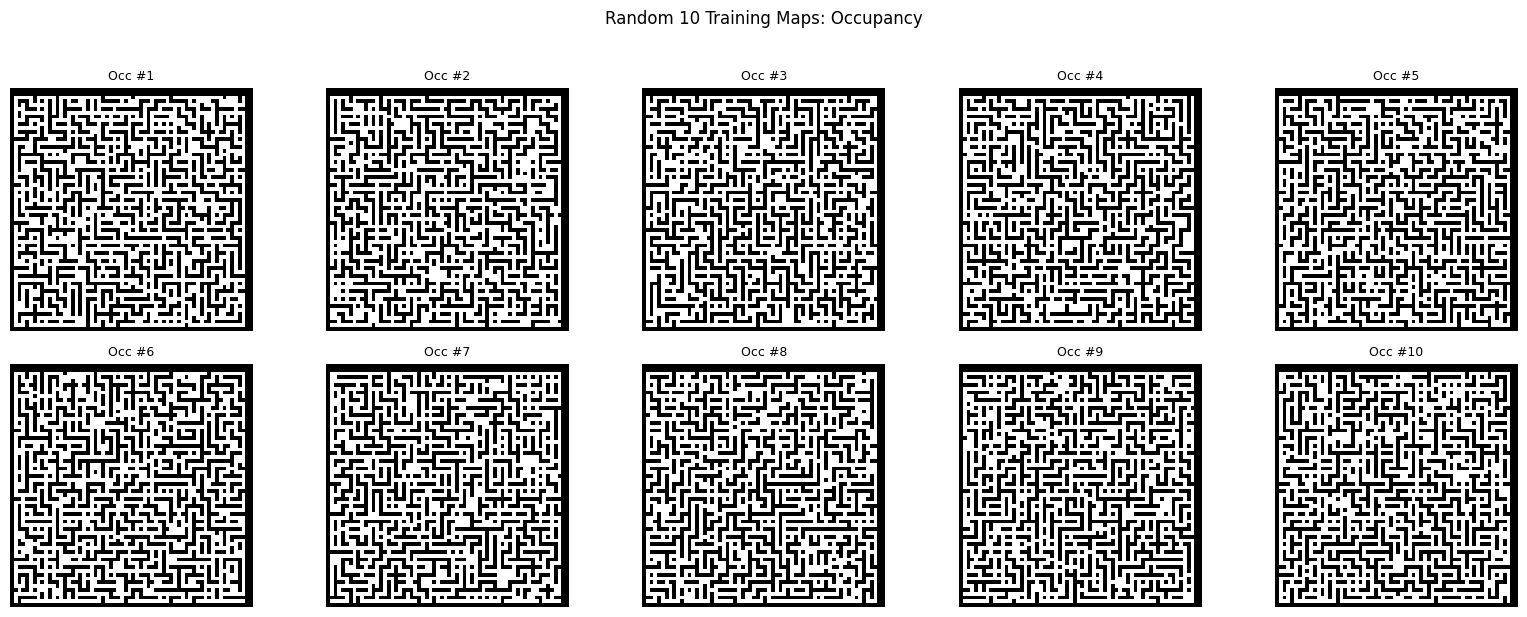

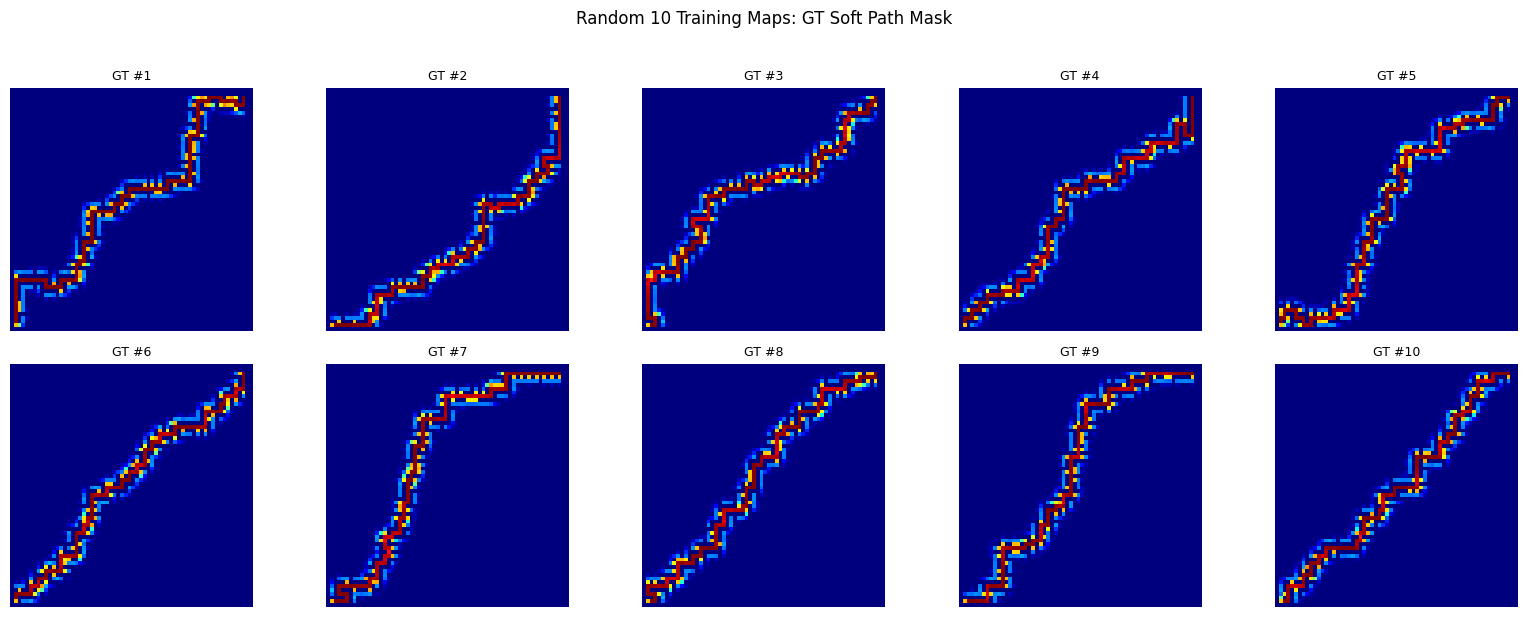


===== Check 2: postprocess free-space masking =====
postprocess contains 'mask_bin *= free_mask': True
Postprocess wall-pixel ratio mean: 0.000000
Postprocess wall-pixel ratio max : 0.000000
✅ Postprocess wall masking looks correct on sampled maps.

===== Check 3: path_found definition gap =====
path_found rate                   : 1.000
endpoint-connected rate           : 0.100
strict success rate (endpoint err): 1.000
path_found but NOT endpoint-conn  : 0.900
⚠️ path_found is optimistic; use endpoint-connected / strict success as your main metric.


In [13]:
# --- Check Suite (10 training maps): GT quality + wall masking + path_found gap ---
import random
import inspect
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label

N_SAMPLE = 10
GT_TINY = 0.05
THR_GT = 0.35
ENDPOINT_RADIUS = ENDPOINT_DISK_RADIUS if 'ENDPOINT_DISK_RADIUS' in globals() else 2
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


def _disk_mask_local(shape, center_rc, radius):
    h, w = shape
    rr, cc = np.ogrid[:h, :w]
    cr, cc0 = int(center_rc[0]), int(center_rc[1])
    return ((rr - cr) ** 2 + (cc - cc0) ** 2) <= (radius ** 2)


def same_component_endpoint(mask_bin, start_rc, goal_rc, endpoint_radius=2):
    labeled, num = label(mask_bin.astype(bool))
    if num == 0:
        return False

    if '_disk_mask_numpy' in globals():
        start_disk = _disk_mask_numpy(mask_bin.shape, start_rc, endpoint_radius)
        goal_disk = _disk_mask_numpy(mask_bin.shape, goal_rc, endpoint_radius)
    else:
        start_disk = _disk_mask_local(mask_bin.shape, start_rc, endpoint_radius)
        goal_disk = _disk_mask_local(mask_bin.shape, goal_rc, endpoint_radius)

    for comp_id in range(1, num + 1):
        comp = (labeled == comp_id)
        if np.logical_and(comp, start_disk).any() and np.logical_and(comp, goal_disk).any():
            return True
    return False


# ------------------------------
# Check 1: GT quality on training maps
# ------------------------------
train_items = [v for _, v in map_dictionary.items() if v.get('smooth_path') is not None]
if len(train_items) == 0:
    raise RuntimeError('No valid training items with smooth_path in map_dictionary.')

sample_n = min(N_SAMPLE, len(train_items))
sampled = random.sample(train_items, sample_n)

occ_list = []
gt_list = []
gt_collision_list = []
gt_connected_list = []

for item in sampled:
    occ = item['map'].astype(np.float32)
    gt_mask = build_soft_mask_from_item(item, map_size=IMG_SIZE, path_sigma=PATH_BRUSH_SIGMA)

    support = (gt_mask > GT_TINY)
    support_n = int(support.sum())
    wall_overlap_n = int(np.logical_and(support, occ > 0.5).sum())
    gt_collision = wall_overlap_n / max(support_n, 1)

    gt_bin = (gt_mask > THR_GT)
    gt_connected = same_component_endpoint(gt_bin, item['start'], item['goal'], endpoint_radius=ENDPOINT_RADIUS)

    occ_list.append(occ)
    gt_list.append(gt_mask)
    gt_collision_list.append(float(gt_collision))
    gt_connected_list.append(bool(gt_connected))

print('===== Check 1: GT quality (10 training maps) =====')
print(f'Sampled maps            : {sample_n}')
print(f'GT collision mean       : {np.mean(gt_collision_list):.6f}')
print(f'GT collision max        : {np.max(gt_collision_list):.6f}')
print(f'GT connected rate       : {np.mean(gt_connected_list):.3f}')
if np.mean(gt_connected_list) < 0.9:
    print('⚠️ GT endpoint connectivity is low -> model can learn broken endpoints.')
if np.max(gt_collision_list) > 0.01:
    print('⚠️ GT overlaps walls on some maps -> model can learn wall crossing.')

# plot occupancy maps
cols = 5
rows = int(np.ceil(sample_n / cols))
plt.figure(figsize=(3.2 * cols, 3.0 * rows))
for i in range(sample_n):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(occ_list[i], cmap='Greys', origin='lower')
    plt.title(f'Occ #{i+1}', fontsize=9)
    plt.axis('off')
plt.suptitle('Random 10 Training Maps: Occupancy', y=1.02)
plt.tight_layout()
plt.show()

# plot gt masks
plt.figure(figsize=(3.2 * cols, 3.0 * rows))
for i in range(sample_n):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(gt_list[i], cmap='jet', origin='lower', vmin=0.0, vmax=1.0)
    plt.title(f'GT #{i+1}', fontsize=9)
    plt.axis('off')
plt.suptitle('Random 10 Training Maps: GT Soft Path Mask', y=1.02)
plt.tight_layout()
plt.show()


# ------------------------------
# Check 2: verify postprocess includes free-space masking
# ------------------------------
print('\n===== Check 2: postprocess free-space masking =====')
try:
    src = inspect.getsource(postprocess_mask)
    has_projection = 'mask_bin = mask_bin * free_mask.astype(np.float32)' in src
    print(f"postprocess contains 'mask_bin *= free_mask': {has_projection}")
except Exception as e:
    print(f'Could not inspect postprocess source: {e}')

obstacle_ratio_after_post = []
for item in sampled:
    occ = item['map'].astype(np.float32)
    cond = build_cond_from_item(item, map_size=IMG_SIZE, sigma=START_GOAL_SIGMA)
    with torch.no_grad():
        prob = generate_path_mask(cond).detach().cpu().numpy()

    _, mask_bin = select_threshold_by_connectivity(
        prob,
        free_mask=(1.0 - occ),
        start_rc=item['start'],
        goal_rc=item['goal'],
        thr_values=THR_CANDIDATES,
        use_lcc=USE_LARGEST_CC,
    )

    support = (mask_bin > 0.5)
    wall_pix = np.logical_and(support, occ > 0.5)
    ratio = float(wall_pix.sum()) / max(int(support.sum()), 1)
    obstacle_ratio_after_post.append(ratio)

print(f'Postprocess wall-pixel ratio mean: {np.mean(obstacle_ratio_after_post):.6f}')
print(f'Postprocess wall-pixel ratio max : {np.max(obstacle_ratio_after_post):.6f}')
if np.max(obstacle_ratio_after_post) > 1e-4:
    print('⚠️ Still leaking wall pixels after postprocess in some samples.')
else:
    print('✅ Postprocess wall masking looks correct on sampled maps.')


# ------------------------------
# Check 3: path_found metric gap
# ------------------------------
print('\n===== Check 3: path_found definition gap =====')
path_found_flags = []
endpoint_connected_flags = []
strict_success_flags = []

for item in sampled:
    occ = item['map'].astype(np.float32)
    cond = build_cond_from_item(item, map_size=IMG_SIZE, sigma=START_GOAL_SIGMA)
    with torch.no_grad():
        prob = generate_path_mask(cond).detach().cpu().numpy()

    _, mask_bin = select_threshold_by_connectivity(
        prob,
        free_mask=(1.0 - occ),
        start_rc=item['start'],
        goal_rc=item['goal'],
        thr_values=THR_CANDIDATES,
        use_lcc=USE_LARGEST_CC,
    )

    skel, raw_path, final_path = extract_final_path(
        mask_bin,
        item['start'],
        item['goal'],
        closing_iter=SKELETON_PRE_CLOSING,
        dilation_iter=SKELETON_PRE_DILATION,
        path_length=PATH_LENGTH,
        prob_mask=prob,
        free_mask=(1.0 - occ),
    )

    path_found = (final_path is not None)
    endpoint_connected = same_component_endpoint(mask_bin > 0.5, item['start'], item['goal'], endpoint_radius=ENDPOINT_RADIUS)

    if final_path is None:
        strict_success = False
    else:
        e_start, e_goal = endpoint_errors(final_path, item['start'], item['goal'])
        strict_success = bool(e_start <= END_DIST_THR and e_goal <= END_DIST_THR)

    path_found_flags.append(path_found)
    endpoint_connected_flags.append(endpoint_connected)
    strict_success_flags.append(strict_success)

mismatch = [pf and (not ec) for pf, ec in zip(path_found_flags, endpoint_connected_flags)]
print(f'path_found rate                   : {np.mean(path_found_flags):.3f}')
print(f'endpoint-connected rate           : {np.mean(endpoint_connected_flags):.3f}')
print(f'strict success rate (endpoint err): {np.mean(strict_success_flags):.3f}')
print(f'path_found but NOT endpoint-conn  : {np.mean(mismatch):.3f}')
if np.mean(mismatch) > 0.05:
    print('⚠️ path_found is optimistic; use endpoint-connected / strict success as your main metric.')
else:
    print('✅ path_found is mostly aligned with endpoint-connected success.')